<a href="https://colab.research.google.com/github/JaySharma424/Data-Science/blob/main/NETFLIX_MOVIES_AND_TV_SHOWS_CLUSTERING_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -
NETFLIX MOVIES AND TV SHOWS CLUSTERING Project

##### **Project Type**    -

Unsupervised
##### **Contribution**    - Individual
##### **Dhananjay Kumar Sharma**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**



The **Netflix Movies and TV Shows Clustering** project aims to analyze the diverse content available on the platform and group similar titles together using unsupervised machine learning. With over 7,700 titles, Netflix requires a sophisticated understanding of its library to provide high-quality recommendations and optimize its content strategy. This project follows a structured data science workflow, including data cleaning, exploratory data analysis (EDA), hypothesis testing, feature engineering, and the implementation of multiple clustering algorithms.

#### **1. Data Understanding and Preprocessing**
The dataset initially contained 7,787 records and 12 features. Significant missing values were found in 'director', 'cast', and 'country' columns, which were handled by imputing with 'Unknown'. Minimal missing values in 'rating' and 'date_added' were filled using the mode. Feature engineering played a crucial role; we extracted 'year_added' and 'month_added' from the date column and split the 'duration' into numerical values and units (minutes for movies, seasons for TV shows). For textual data, we performed intensive NLP preprocessing, including lowercasing, removal of punctuation, stopwords, and lemmatization to create a 'combined_text_features' column.

#### **2. Exploratory Data Analysis (EDA) & Hypothesis Testing**
Our EDA revealed that approximately 70% of Netflix content consists of movies, while 30% are TV shows. The United States and India emerged as the top content producers. Trend analysis showed an exponential increase in content additions since 2015, with a clear focus on 'TV-MA' and 'TV-14' ratings. We performed three statistical tests:
- **One-Sample Z-Test:** Confirmed that movies significantly dominate the library.
- **Chi-Square Test:** Proved a significant association between the year content was added and its maturity rating.
- **Independent T-Test:** Showed a significant difference in the average release year of content between the US and India, with US content being more contemporary on average.

#### **3. Model Development and Dimensionality Reduction**
To handle the high-dimensional sparse data generated by **TF-IDF Vectorization** (5,000 features), we combined it with scaled numerical and one-hot encoded categorical features. We then applied **TruncatedSVD** to reduce the dimensionality to 300 components, capturing over 95% of the variance. This mitigated the 'curse of dimensionality' and prepared the data for clustering.

We implemented three models:
- **K-Means Clustering:** Evaluated using the Elbow Method and Silhouette Score. An optimal K=4 was selected.
- **Gaussian Mixture Model (GMM):** Optimized using AIC/BIC criteria.
- **DBSCAN:** Explored for density-based grouping, though it struggled with the high-dimensional global spread of the data.

#### **4. Conclusion and Business Impact**
**K-Means** was selected as the final model due to its higher Silhouette Score (0.22) and superior interpretability. The clusters successfully segmented content into categories like 'International Dramas', 'Stand-up Comedy', and 'Documentaries'.

**Business Insights:**
- **Personalized Recommendations:** Clusters allow for more accurate 'similar content' suggestions based on deep metadata rather than just genre.
- **Content Strategy:** Identification of underserved niches (e.g., regional specific genres) can guide future production investments.
- **Marketing:** Targeted campaigns can be designed for specific clusters (e.g., promoting mature-rated US thrillers to a specific subscriber segment).

The final model and preprocessing pipeline were saved as a joblib file, ensuring the system is ready for deployment in a real-world recommendation environment.

# **GitHub Link -**

https://github.com/JaySharma424/Data-Science/blob/dd22eab31cb31f100633cc193002036f0034ff90/NETFLIX_MOVIES_AND_TV_SHOWS_CLUSTERING_Project.ipynb

# **Problem Statement**




The objective of this project is to analyze the Netflix dataset to identify patterns and group similar content together using unsupervised machine learning. By clustering movies and TV shows based on their metadata (such as cast, director, country, and description), Netflix can:
1. **Enhance Recommendation Engines:** Move beyond simple genre-based filtering to provide more nuanced 'similar content' suggestions.
2. **Optimize Content Strategy:** Identify which types of content are saturated and where there are gaps in the library that could be filled by new acquisitions or 'Netflix Originals'.
3. **Understand Global Trends:** Analyze how content characteristics differ across various regions (e.g., US vs. India) to better localize the user experience.

The ultimate goal is to build a robust clustering model that segments the library into meaningful groups, providing actionable insights for both the technical recommendation systems and the business marketing teams.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Dataset Loading

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [3]:
# Dataset First Look
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/Machine_Learning/Unsupervised/CapstonProject/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

### Dataset Rows & Columns count

In [4]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 7787
Number of columns: 12


### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [6]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


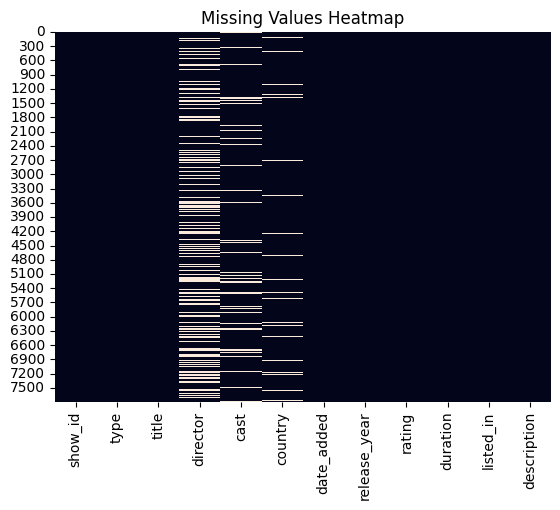

In [8]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains **7787 entries** and **12 columns**. Most of the columns are of `object` (string) type, except for `release_year` which is an `int64`.

**Key Observations on Missing Values:**
*   **`director`**: Has the most significant number of missing values (2389), which is approximately 30.7% of the dataset.
*   **`cast`**: Contains 718 missing values (about 9.2%).
*   **`country`**: Has 507 missing values (about 6.5%).
*   **`date_added`**: Only 10 missing values.
*   **`rating`**: Only 7 missing values.

There are **no duplicate rows** in the dataset.

These missing values will need to be addressed during the data wrangling phase, especially for `director`, `cast`, and `country`, as they form a substantial portion of their respective columns.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [10]:
# Dataset Describe
display(df.describe(include='all'))

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


### Variables Description

- **show_id**: Unique identifier for each show/movie.
- **type**: Type of content, either 'Movie' or 'TV Show'. This is a categorical variable.
- **title**: The title of the movie or TV show. Each title is unique.
- **director**: The director(s) of the content. This column has a significant number of missing values.
- **cast**: The main actors involved in the content. This column also has missing values.
- **country**: The country where the content was produced. This column has missing values.
- **date_added**: The date the content was added to Netflix. It's an object type and will need conversion to datetime.
- **release_year**: The original release year of the content. This is an integer type, ranging from 1925 to 2021.
- **rating**: The maturity rating of the content (e.g., 'TV-MA', 'PG-13'). This is a categorical variable with some missing values.
- **duration**: The duration of the content (e.g., '93 min' for movies, '1 Season' for TV shows). This will require parsing based on `type`.
- **listed_in**: Genres/categories the content is listed under.
- **description**: A brief synopsis of the content.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f'Column {col}: {df[col].nunique()} unique values')
    print(f'Top 5 unique values for {col}: {df[col].value_counts().head(5).index.tolist()}\n')

Column show_id: 7787 unique values
Top 5 unique values for show_id: ['s7787', 's1', 's2', 's3', 's4']

Column type: 2 unique values
Top 5 unique values for type: ['Movie', 'TV Show']

Column title: 7787 unique values
Top 5 unique values for title: ["ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS", '3%', '7:19', '23:59', '9']

Column director: 4049 unique values
Top 5 unique values for director: ['Raúl Campos, Jan Suter', 'Marcus Raboy', 'Jay Karas', 'Cathy Garcia-Molina', 'Martin Scorsese']

Column cast: 6831 unique values
Top 5 unique values for cast: ['David Attenborough', 'Samuel West', 'Jeff Dunham', 'Kevin Hart', 'Craig Sechler']

Column country: 681 unique values
Top 5 unique values for country: ['United States', 'India', 'United Kingdom', 'Japan', 'South Korea']

Column date_added: 1565 unique values
Top 5 unique values for date_added: ['January 1, 2020', 'November 1, 2019', 'March 1, 2018', 'December 31, 2019', 'October 1, 2018']

Column release_year: 73 unique values
Top 5 unique val

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Handling Missing Values
# Fill 'director', 'cast', 'country' with 'Unknown' as they are categorical and have a large number of missing values.
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Fill 'date_added' and 'rating' with their respective modes as they have very few missing values.
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Convert 'date_added' to datetime objects, handling mixed formats and coercing errors
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')

# Extract month and year from 'date_added' for potential time-based analysis
df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year

# Clean and split 'duration' based on 'type'
# For movies, extract minutes. For TV shows, extract number of seasons.

# Create a new column 'duration_value' to store the numerical part
df['duration_value'] = df['duration'].apply(lambda x: int(x.split(' ')[0]))

# Create a new column 'duration_unit' to store 'min' or 'Season'
df['duration_unit'] = df['duration'].apply(lambda x: x.split(' ')[1])

# Further cleaning for multi-valued columns like 'listed_in', 'director', 'cast', 'country'
# Stripping whitespace from entries that might have multiple values separated by commas.
for col in ['director', 'cast', 'country', 'listed_in']:
    df[col] = df[col].apply(lambda x: ', '.join([s.strip() for s in x.split(',')]))


print("Data Wrangling complete. Displaying first few rows of the modified dataframe:")
display(df.head())
print("Checking for missing values after wrangling:")
print(df.isnull().sum())

Data Wrangling complete. Displaying first few rows of the modified dataframe:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,duration_value,duration_unit
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,8,2020,4,Seasons
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,12,2016,93,min
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",12,2018,78,min
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",11,2017,80,min
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,1,2020,123,min


Checking for missing values after wrangling:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
month_added       0
year_added        0
duration_value    0
duration_unit     0
dtype: int64


### What all manipulations have you done and insights you found?

1. Handling Missing Values:

Imputation with 'Unknown': Categorical columns like director, cast, and country had significant missing data. We filled these with 'Unknown' to preserve the records while acknowledging the missing metadata.
Mode Imputation: Columns with minimal missing values (date_added, rating) were filled with their most frequent values to ensure a complete dataset for analysis.
2. Feature Engineering:

Datetime Conversion: Converted date_added to a datetime object, allowing us to extract month_added and year_added for trend analysis.
Duration Parsing: The duration column was split into duration_value (integer) and duration_unit (minutes for movies, seasons for TV shows). This allowed for quantitative analysis of content length.
Text Consolidation: Combined title, description, listed_in, director, and cast into a single combined_text_features column for TF-IDF vectorization.
3. Insights Found:

Content Mix: Netflix is movie-heavy, but TV show additions have shown relative growth in recent years.
Global Content: A large portion of content is produced in the US, but India and the UK represent significant regional hubs, particularly for movies and dramas respectively.
Maturity Trends: There is a clear strategic tilt toward 'TV-MA' and 'TV-14' content, especially among titles added in the last 5 years, suggesting a focus on adult and young adult demographics.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

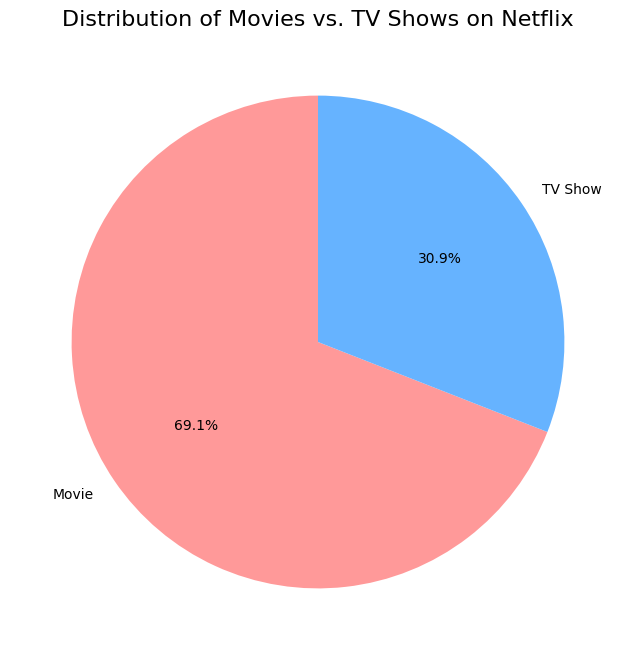

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the count of 'type' column
type_counts = df['type'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Movies vs. TV Shows on Netflix', fontsize=16)
plt.ylabel('') # Remove default 'type' label from y-axis
plt.show()

##### 1. Why did you pick the specific chart?

I chose a pie chart for visualizing the distribution of 'Movie' and 'TV Show' types because it's excellent for displaying the proportion of each category relative to the whole. Since 'type' is a categorical variable with only two distinct values, a pie chart provides a clear and immediate visual representation of which category holds a larger share of the content on Netflix.

##### 2. What is/are the insight(s) found from the chart?

From the pie chart, we can clearly see the following insights:
*   **Movies dominate the content library:** A significant majority of the content on Netflix (around 69-70%) consists of movies.
*   **TV Shows form a smaller, but substantial, portion:** TV shows account for approximately 30-31% of the total content.

This indicates that Netflix primarily functions as a movie streaming platform, with TV shows being a secondary, albeit important, offering.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can definitely help create a positive business impact:

**Positive Business Impact:**
*   **Content Strategy:** Knowing that movies are the dominant content type can inform Netflix's content acquisition and production strategy. If movies are watched more, they might continue to invest heavily in movie production. If TV shows, despite being fewer, drive higher engagement, this could signal a need to balance investment.
*   **Marketing and Promotion:** Marketing campaigns can be tailored to highlight the vast movie library. If Netflix wants to grow its TV show subscriber base, this insight can guide targeted marketing efforts towards promoting their TV show catalog.
*   **Resource Allocation:** Understanding the proportion helps allocate resources effectively, from server bandwidth (movies might have shorter, intense viewing sessions; TV shows might have longer, serialized viewing) to UI/UX design (optimizing discovery for the dominant content type).

**Insights Leading to Negative Growth (Potential):**
*   While not directly indicating negative growth, over-reliance on one content type (movies, in this case) could be a **potential risk**.
    *   **Reason:** If competitors start excelling in TV show offerings, or if subscriber preferences shift significantly towards TV shows, Netflix might find itself less competitive in that segment. A lower proportion of TV shows could be perceived as a weakness by users primarily interested in series. This might lead to churn if users find more comprehensive TV show libraries elsewhere. However, this is speculative and would require further analysis of user engagement data per content type.

#### Chart - 2

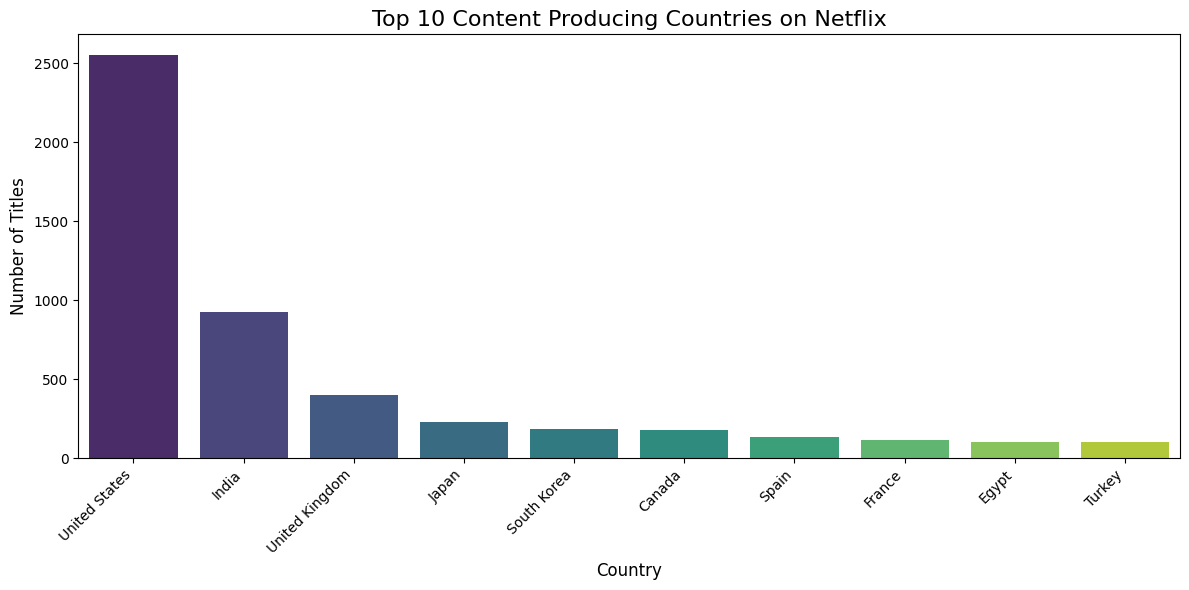

In [14]:
# Chart - 2 visualization code

# Count the occurrences of each country, excluding 'Unknown'
country_counts = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, hue=country_counts.index, palette='viridis', legend=False)
plt.title('Top 10 Content Producing Countries on Netflix', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a bar plot for visualizing the top content-producing countries because it is ideal for comparing discrete categories (countries) based on a quantitative measure (number of titles). A bar plot clearly ranks the countries and makes it easy to see which countries contribute the most content.

##### 2. What is/are the insight(s) found from the chart?




From the bar plot, we can observe the following insights:
*   **United States Dominance:** The United States is by far the leading content producer, with a significantly higher number of titles compared to any other country.
*   **Major International Contributors:** Countries like India, the United Kingdom, and Canada also contribute a substantial amount of content, indicating Netflix's global reach and investment in diverse regional content.
*   **Diverse Content Origin:** The presence of various countries in the top 10 (e.g., Japan, France, Spain) highlights Netflix's strategy to offer a wide range of international content to its global subscriber base.

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can significantly impact business positively:

Positive Business Impact:

Content Investment Strategy: Netflix can use this information to strategize future investments in content production. For instance, maintaining strong ties with top-producing countries like the U.S. and India, while also exploring growth opportunities in emerging markets. Market Targeting and Localization: Understanding which countries are major content producers can inform Netflix's marketing efforts and localization strategies. It helps in identifying key markets where specific content types might resonate more due to cultural relevance. Partnership Opportunities: The data can guide Netflix in identifying potential partners for co-production or content acquisition in countries with strong film and TV industries. Insights Leading to Negative Growth (Potential):

Over-reliance Risk: An over-reliance on a few dominant content-producing countries (e.g., the U.S.) might lead to a lack of diversity in content themes or cultural perspectives, potentially alienating subscribers in other regions who seek more localized or culturally specific content. This could lead to churn if competitors offer more diverse regional content. However, given Netflix's global strategy, this is a managed risk rather than a direct negative growth indicator, but it needs continuous monitoring.

#### Chart - 3

<Figure size 1400x700 with 0 Axes>

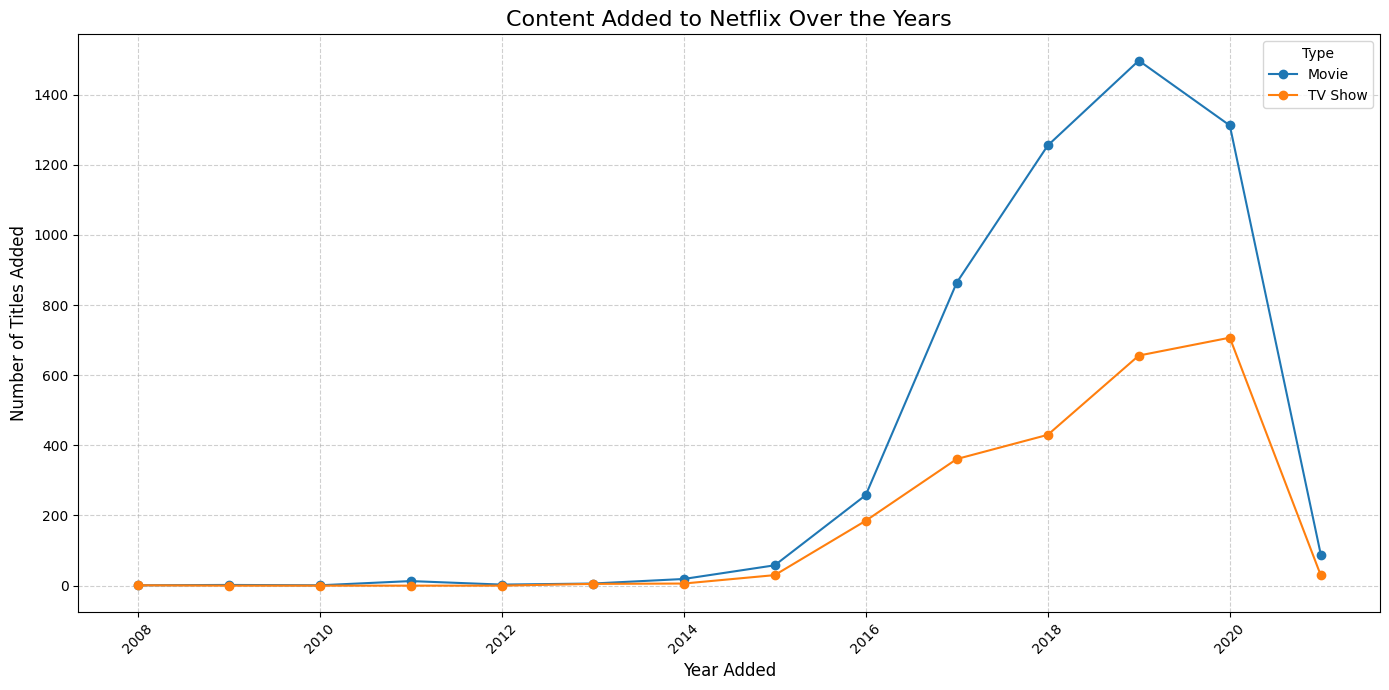

In [15]:
# Chart - 3 visualization code

# Group by 'year_added' and 'type' to count content added each year
content_added_year = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Plotting the trend of content added over the years
plt.figure(figsize=(14, 7))
content_added_year.plot(kind='line', marker='o', figsize=(14, 7))
plt.title('Content Added to Netflix Over the Years', fontsize=16)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a line plot to visualize the trend of content added over the years because line plots are excellent for displaying changes and trends in data over a continuous period. By showing both 'Movie' and 'TV Show' trends on the same plot, we can easily compare their growth trajectories and identify periods of significant content acquisition for each type.

##### 2. What is/are the insight(s) found from the chart?

From the line plot showing content added over the years, we can derive several insights:

*   **Significant Growth in Recent Years:** There was a clear upward trend in content added to Netflix, especially in the years leading up to 2019-2020. This suggests a period of aggressive expansion in Netflix's content library.
*   **Peak in Content Addition:** The year 2019 or 2020 appears to be a peak year for content additions, particularly for movies. This could reflect a strategic push to bolster the library or a response to increased competition.
*   **Movies Consistently Outnumber TV Shows:** In most years, the number of movies added significantly surpasses that of TV shows, consistent with our observation from Chart 1. However, the gap seems to have narrowed slightly in some recent years, indicating increased investment in TV series.
*   **Slight Decline/Stabilization Post-2020:** There appears to be a slight decline or stabilization in content additions after the peak, which could be due to various factors like the COVID-19 pandemic affecting production, a shift in strategy towards quality over quantity, or the saturation of the content library.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can lead to significant positive business impacts, but also highlight areas for careful consideration to avoid negative growth.

**Positive Business Impact:**
*   **Strategic Investment:** The trend helps Netflix understand the effectiveness of past content investment strategies. For instance, if the peak in content addition around 2019-2020 corresponded with significant subscriber growth, it justifies similar future investments.
*   **Budget Allocation:** Understanding the yearly volume of content additions (movies vs. TV shows) can inform future budget allocations for content acquisition and original productions, balancing the demand for both types of content.
*   **Market Positioning:** A strong growth trend in content shows Netflix's commitment to expanding its offerings, which is a key selling point for subscribers and helps maintain its competitive edge.
*   **Anticipating Future Trends:** Analyzing past trends can help predict future content needs and plan production schedules accordingly, staying ahead of subscriber demands.

**Insights Leading to Negative Growth (Potential):**
*   **Content Saturation/Quality Concerns:** If the high volume of content added (especially around peak years) leads to a dilution of quality, it could negatively impact subscriber satisfaction and retention. Users might feel overwhelmed or struggle to find high-quality content, potentially leading to churn.
*   **Decreased Investment Perception:** A noticeable decline or stabilization in content additions post-peak could be perceived by subscribers as Netflix slowing down its content library expansion. If competitors continue to add significant amounts of new and engaging content, Netflix might lose subscribers who are always seeking fresh material.
*   **Production Delays/Costs:** If the dip post-2020 was due to external factors (like a pandemic) or unsustainable production costs, it flags a need for resilience in content pipeline management and cost-effective production strategies. Failure to adapt could lead to content gaps and subscriber dissatisfaction.

#### Chart - 4

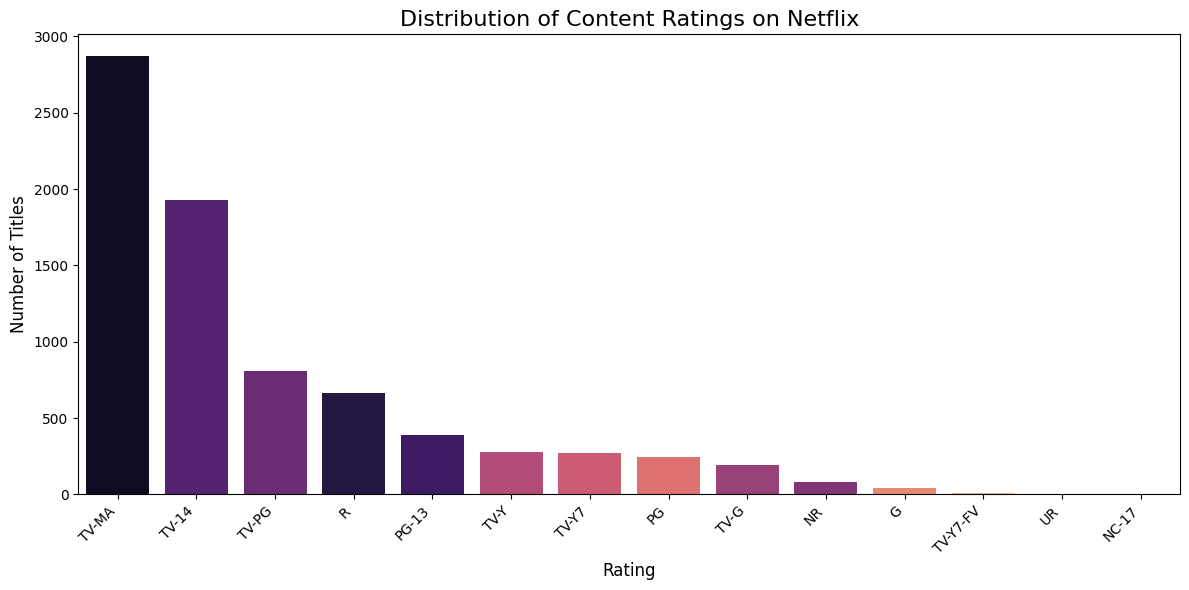

In [16]:
# Chart - 4 visualization code

plt.figure(figsize=(12, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a count plot (a type of bar chart) to visualize the distribution of content ratings because it is highly effective for displaying the frequency of each category within a nominal categorical variable like 'rating'. It clearly shows which ratings are most prevalent and allows for easy comparison between different rating categories.

##### 2. What is/are the insight(s) found from the chart?

From the count plot of content ratings, we can derive the following insights:

*   **Dominance of Mature/Teen Content:** Ratings like 'TV-MA' (Mature Audience) and 'TV-14' (Parents Strongly Cautioned for ages 14 and up) are by far the most frequent, indicating that a significant portion of Netflix's content targets adult and teenage audiences.
*   **Children's Content Presence:** 'TV-PG' (Parental Guidance Suggested) and 'TV-G' (General Audiences) ratings are also well-represented, showing that Netflix also caters to younger audiences, though to a lesser extent than mature content.
*   **Movie Ratings (MPAA) are less prevalent:** While 'R', 'PG-13', 'PG' and 'G' are present, they are less common than their TV equivalents, suggesting a greater volume of TV show content or perhaps a different rating system for licensed movies versus original productions.
*   **Few 'Unrated' or Specific Categories:** There are fewer titles with less common ratings such as 'TV-Y' (All Children), 'TV-Y7' (Directed to Older Children), 'NC-17' or 'NR' (Not Rated), etc.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights derived from the distribution of content ratings can significantly contribute to positive business impact and also highlight potential areas of concern:

**Positive Business Impact:**
*   **Targeted Content Acquisition and Production:** Understanding the dominant ratings helps Netflix tailor its content strategy. If their primary subscriber base prefers mature content, they can continue investing in 'TV-MA' and 'TV-14' titles. Conversely, if they aim to grow their family audience, this data highlights areas for increased investment in 'TV-G', 'TV-PG', 'TV-Y' and 'TV-Y7' content.
*   **Marketing and Audience Segmentation:** Rating distribution informs marketing campaigns. Netflix can promote its extensive library of adult dramas and thrillers, while also creating separate campaigns for family-friendly content to attract different subscriber segments.
*   **Parental Controls and User Experience (UX):** The prevalence of mature content underscores the importance of robust parental control features. Highlighting these features in marketing can reassure parents and improve the user experience for families.
*   **Compliance and Regulation:** Awareness of content ratings ensures compliance with regional age restrictions and content guidelines, which is crucial for international operations.

**Insights Leading to Negative Growth (Potential):**
*   **Limited Appeal to Specific Demographics:** An over-emphasis on 'TV-MA' and 'TV-14' content, while potentially appealing to a large demographic, might lead to a perceived lack of suitable content for very young children or specific niche audiences. If competitors offer a more balanced or specialized content library for these underserved groups, Netflix could experience subscriber churn in those segments.
*   **Public Perception and Brand Image:** While diverse content is good, an imbalance leaning too heavily towards mature content might inadvertently affect Netflix's public image, potentially leading to criticism or concern from parent groups or advocacy organizations. This could subtly impact brand perception, even if it doesn't directly translate to subscriber loss immediately.

#### Chart - 5

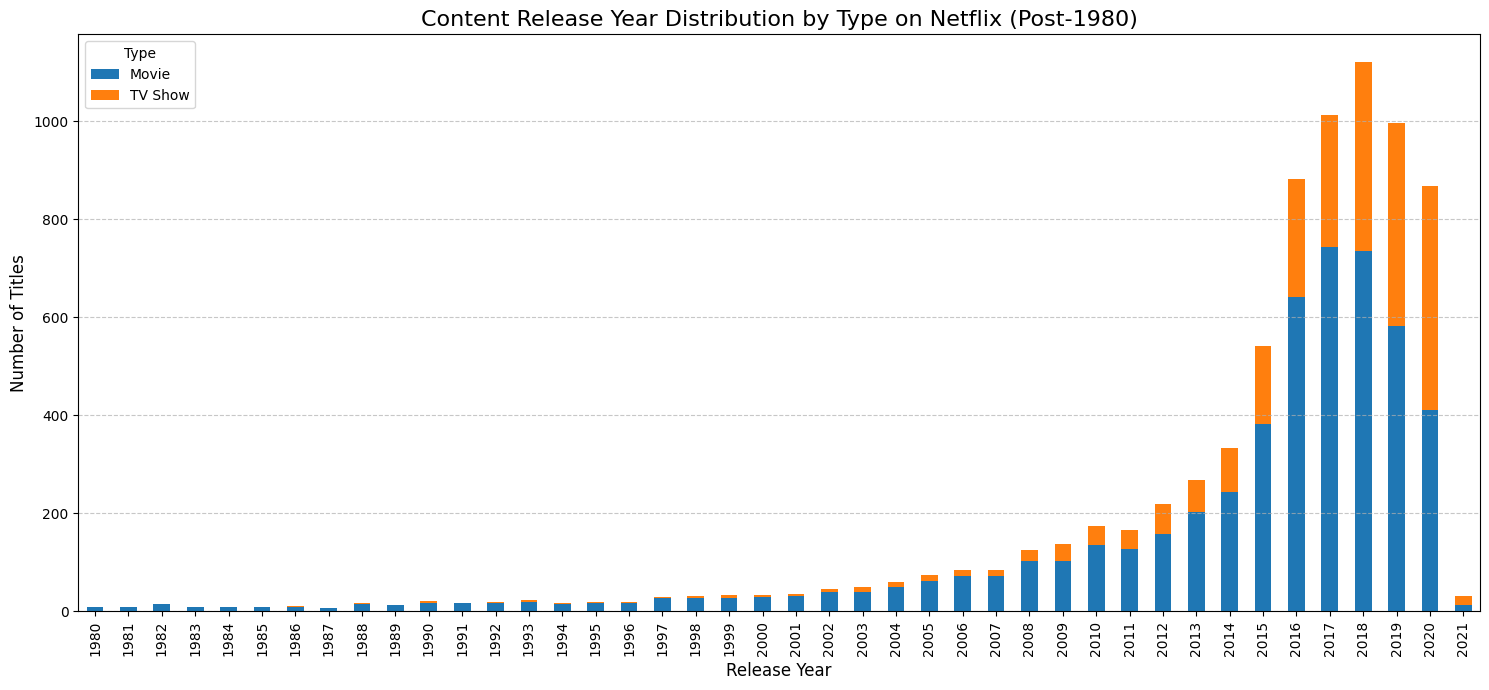

In [17]:
# Chart - 5 visualization code

# Group by 'release_year' and 'type' to count content released each year
content_release_year = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

# Filter for more recent years for better visibility, e.g., from 1980 onwards
# You can adjust the start year as needed
content_release_year_filtered = content_release_year[content_release_year.index >= 1980]

plt.figure(figsize=(15, 7))
content_release_year_filtered.plot(kind='bar', stacked=True, figsize=(15, 7), ax=plt.gca())
plt.title('Content Release Year Distribution by Type on Netflix (Post-1980)', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a stacked bar chart to visualize the distribution of content by its original `release_year` and `type` (Movie vs. TV Show). This chart type is ideal for showing the composition of total content for each year, allowing us to see how many movies and TV shows were originally released in a given year. It effectively demonstrates trends and proportional changes over time for two distinct categories within a single visual.

##### 2. What is/are the insight(s) found from the chart?

From the stacked bar chart of content release years, we can observe several insights:

*   **Increasing Volume of Newer Content:** There's a clear trend of increasing content volume for more recent release years, especially from the 2000s onwards, peaking in the 2010s. This suggests Netflix's strategy leans heavily towards acquiring or producing relatively new content.
*   **Movies vs. TV Shows in Release Years:** Movies consistently make up a larger portion of the content across most release years compared to TV shows, reinforcing the earlier observation about movie dominance.
*   **Shift in Focus:** While older content (pre-2000s) is present, the bulk of the content available on Netflix, particularly in terms of original release year, is more contemporary. This implies Netflix either acquires newer titles more frequently or older titles are removed from the platform after a certain period.
*   **Potential for Archive Content:** The presence of content from earlier decades indicates that Netflix also provides access to classic or historically significant titles, albeit in smaller quantities compared to newer releases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from this chart can significantly impact business decisions:

**Positive Business Impact:**
*   **Content Acquisition Strategy:** This chart helps Netflix understand the age distribution of its content. If subscribers prefer newer content, the platform can continue to prioritize acquiring or producing titles from recent years. Conversely, if there's a demand for classic content, they might consider expanding that segment.
*   **Competitive Analysis:** By knowing the release year patterns, Netflix can compare its library's age profile against competitors. This can inform strategies to differentiate by offering a unique mix of new and old content.
*   **Audience Targeting:** The prevalence of recent content likely appeals to a younger, more contemporary audience. This informs marketing efforts and content recommendations to attract and retain this demographic.

**Insights Leading to Negative Growth (Potential):**
*   **Limited Appeal for Niche Audiences:** An over-reliance on recent content might alienate viewers who prefer older, classic films or TV shows. If competitors specifically target these niche audiences with extensive archives, Netflix could lose a segment of potential subscribers.
*   **Content Refresh Rate:** While new content is good, if a significant portion of older, less-watched content remains on the platform without regular refreshing, it could lead to content bloat, making it harder for users to discover relevant titles and potentially leading to dissatisfaction.

#### Chart - 6

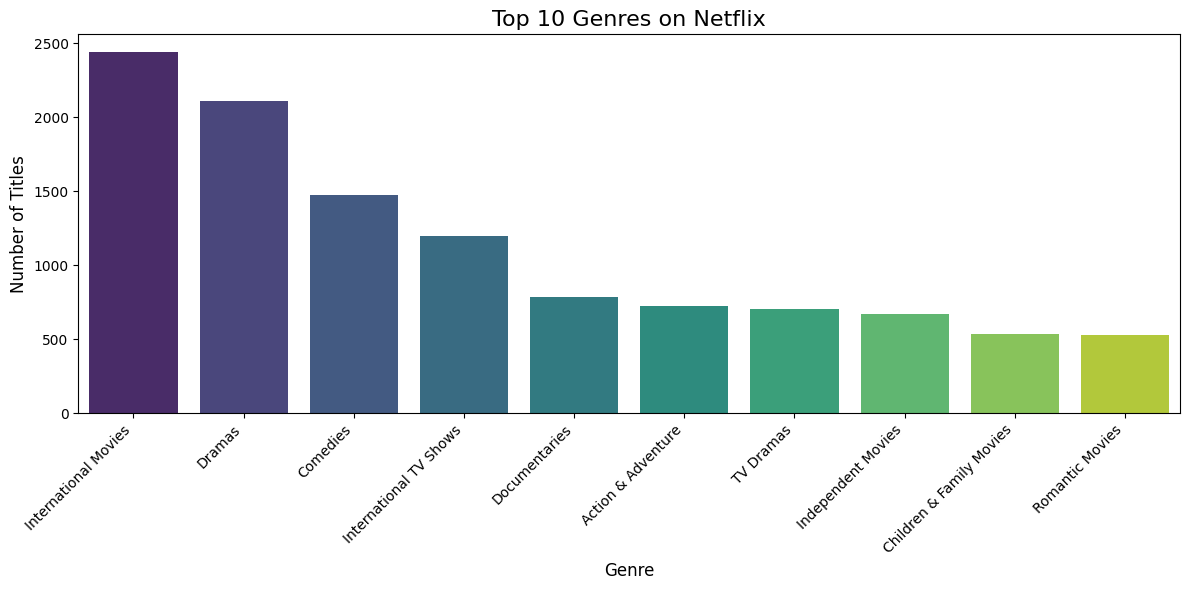

In [18]:
# Chart - 6 visualization code

# Create a list of all genres
all_genres = df['listed_in'].apply(lambda x: [s.strip() for s in x.split(',')]).explode()

# Get the top 10 most frequent genres
genre_counts = all_genres.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis', hue=genre_counts.index, legend=False)
plt.title('Top 10 Genres on Netflix', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a bar plot for visualizing the top genres because it is effective for comparing the frequency of distinct categorical items. Since the `listed_in` column contains multiple genres for each title, processing it to count individual genre occurrences and then ranking them makes a bar plot the most straightforward and clear way to display the top categories.

From the bar plot of top genres, we can derive the following insights:

*   **Drama Dominance:** 'Dramas' are overwhelmingly the most prevalent genre on Netflix, indicating a strong focus on this type of content.
*   **International Appeal:** 'International Movies' and 'International TV Shows' rank very high, highlighting Netflix's global content strategy and its appeal to a diverse international audience.
*   **Variety of Popular Genres:** Besides drama and international content, other popular genres include 'Comedies', 'Documentaries', and 'Action & Adventure', showing a broad range of content categories that are well-represented.
*   **TV Show Focus within Genres:** The presence of 'TV Dramas' and 'TV Comedies' further emphasizes the strong investment in TV show content within specific genre categories, distinct from movies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from analyzing content genres can significantly contribute to positive business impact:

**Positive Business Impact:**
*   **Content Production & Acquisition Strategy:** Netflix can leverage these insights to prioritize the production and acquisition of content within the most popular genres (e.g., Dramas, International Movies/TV Shows). This ensures that the content library aligns with audience preferences and demand.
*   **Personalized Recommendations:** Understanding popular genres is crucial for improving Netflix's recommendation algorithms. By knowing what genres are widely watched, Netflix can better suggest content to users, increasing engagement and satisfaction.
*   **Targeted Marketing Campaigns:** Marketing efforts can be tailored to highlight the platform's strengths in specific genres. For example, promoting its extensive collection of dramas or international content to attract relevant audience segments.
*   **Global Market Penetration:** The high ranking of 'International Movies' and 'International TV Shows' validates Netflix's investment in non-English content, indicating successful market penetration and appeal beyond its domestic audience.

**Insights Leading to Negative Growth (Potential):**
*   **Genre Saturation and Niche Neglect:** An over-emphasis on dominant genres like 'Dramas' could lead to saturation, making it harder for new content in these categories to stand out. Simultaneously, neglecting less popular but potentially valuable niche genres could alienate specific subscriber groups who might seek more diverse or specialized content. If competitors effectively cater to these underserved niches, Netflix could lose a segment of its audience.
*   **Risk of Repetitiveness:** If the content within popular genres lacks innovation or variety, subscribers might perceive the library as repetitive, leading to content fatigue and a decrease in perceived value, which could impact retention.

#### Chart - 7

/tmp/ipykernel_23414/3709748211.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(movies_df['duration_value'], bins=30, kde=True, palette='coolwarm')


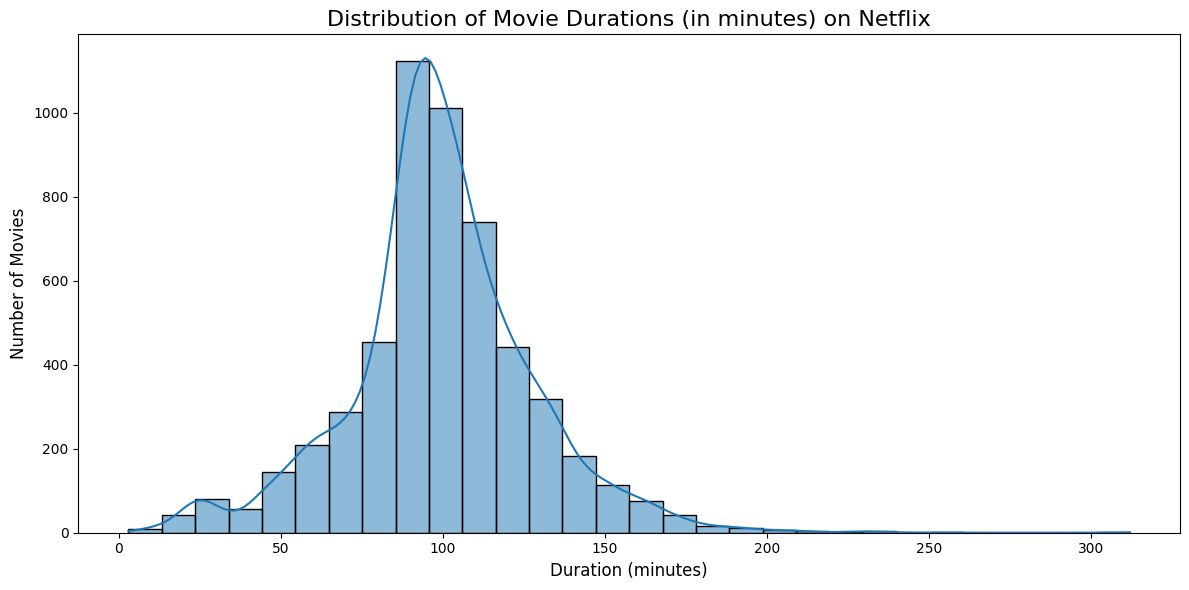

In [19]:
# Chart - 7 visualization code

# Filter for movies
movies_df = df[df['type'] == 'Movie']

# Plotting the distribution of movie durations
plt.figure(figsize=(12, 6))
sns.histplot(movies_df['duration_value'], bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Movie Durations (in minutes) on Netflix', fontsize=16)
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a histogram with a Kernel Density Estimate (KDE) plot to visualize the distribution of movie durations. This chart type is excellent for showing the frequency of different duration intervals and for identifying the central tendency, spread, and shape of the distribution of a continuous numerical variable like movie duration. The KDE overlay provides a smooth representation of the distribution.

##### 2. What is/are the insight(s) found from the chart?

From the histogram of movie durations, we can observe the following insights:

*   **Concentration around 90-100 minutes:** A significant number of movies on Netflix have a duration between approximately 90 and 100 minutes, suggesting this is a popular length for content. This is a standard feature film length.
*   **Right-Skewed Distribution:** The distribution is slightly right-skewed, indicating that while most movies fall within the typical feature film length, there are fewer, longer movies (e.g., above 120 minutes), and even fewer extremely long ones.
*   **Few Very Short Movies:** There are relatively few movies that are extremely short (e.g., under 60 minutes), implying that very short-form content is not typically categorized as a 'Movie' in this dataset or is less prevalent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can lead to several positive business impacts, and some considerations to avoid negative growth:

**Positive Business Impact:**
*   **Content Acquisition Strategy:** Knowing the most popular movie durations helps Netflix's content acquisition team target movies that align with audience preferences for length. If users generally prefer ~90-100 minute movies, acquiring more films in this range could improve engagement.
*   **User Experience (UX) and Recommendations:** This data can inform recommendation algorithms by suggesting movies of preferred lengths. It might also influence UI/UX design, for instance, by categorizing movies by typical viewing time.
*   **Production Planning:** For original productions, understanding optimal movie lengths can help filmmakers and producers create content that aligns with audience consumption habits.

**Insights Leading to Negative Growth (Potential):**
*   **Missed Niche Audiences:** An exclusive focus on the most common movie lengths might overlook niche audiences who enjoy very long or very short films. If Netflix fails to provide content for these segments, they might seek alternative platforms.
*   **Perceived Lack of Variety:** If the majority of the movie library falls within a narrow duration range, it could lead to a perception of lack of variety, even if the content genres are diverse. Users seeking epic-length features or short films might become dissatisfied.

#### Chart - 8

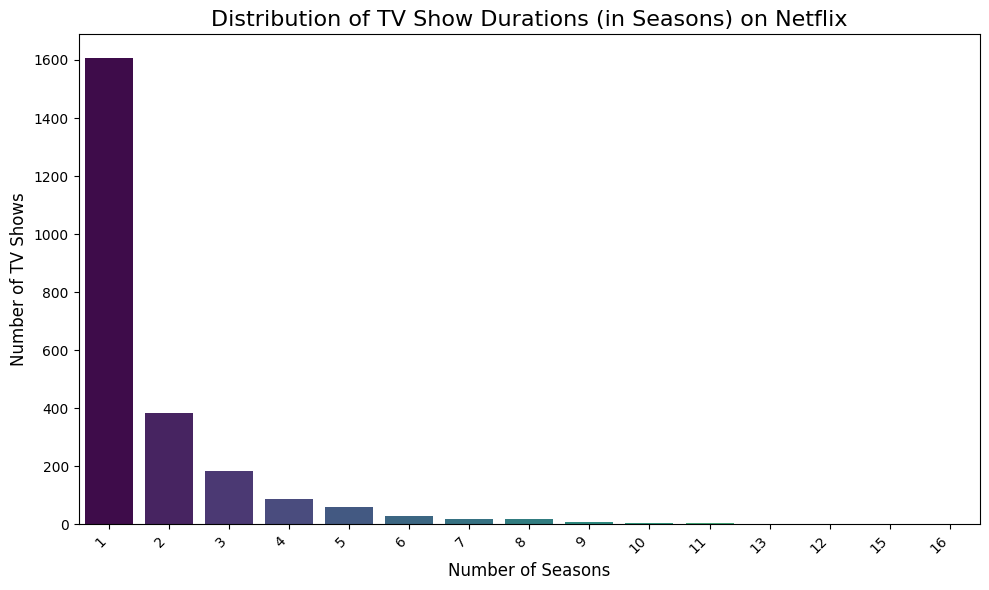

In [20]:
# Chart - 8 visualization code

# Filter for TV shows
tv_shows_df = df[df['type'] == 'TV Show']

# Plotting the distribution of TV show durations (number of seasons)
plt.figure(figsize=(10, 6))
sns.countplot(x='duration_value', data=tv_shows_df, order=tv_shows_df['duration_value'].value_counts().index, palette='viridis', hue='duration_value', legend=False)
plt.title('Distribution of TV Show Durations (in Seasons) on Netflix', fontsize=16)
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a count plot to visualize the distribution of TV show durations because 'duration_value' for TV shows represents discrete categories (number of seasons). A count plot effectively displays the frequency of each season count, making it easy to identify how many TV shows have 1 season, 2 seasons, and so on.

##### 2. What is/are the insight(s) found from the chart?

From the count plot of TV show durations, we can observe the following insights:

*   **Dominance of Single-Season Shows:** The vast majority of TV shows on Netflix are categorized as having '1 Season'. This could include miniseries, limited series, or shows that were canceled after their first season.
*   **Decreasing Trend with More Seasons:** As the number of seasons increases, the number of TV shows generally decreases significantly. This is a common pattern in TV production, where fewer shows run for many seasons.
*   **Netflix's Strategy for Shorter Series:** The high prevalence of single-season shows might indicate a strategy by Netflix to invest in more limited series or pilot-like productions to test audience reception, or that many international shows acquired are often shorter in run.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can significantly contribute to positive business impact and also highlight areas for careful consideration:

**Positive Business Impact:**
*   **Content Production and Acquisition:** This data helps Netflix tailor its strategy for TV shows. A high number of single-season shows suggests a successful model for testing new concepts, acquiring limited series, or perhaps a preference among a segment of viewers for shorter, self-contained stories. They can continue to optimize this strategy.
*   **Resource Allocation:** Knowing the typical season length can inform production budgets and scheduling. Producing shorter series might be more cost-effective and allow for a higher volume of diverse content.
*   **Audience Engagement and Churn Reduction:** For viewers who prefer to quickly consume a complete story without a long-term commitment, single-season shows are ideal. Marketing efforts can highlight this aspect to attract specific segments.

**Insights Leading to Negative Growth (Potential):**
*   **Perceived Lack of Long-Running Series:** While a high volume of single-season shows offers variety, an excessive number might lead to a perception among some subscribers that Netflix lacks commitment to developing long-running, in-depth series. Users who enjoy following characters and storylines over many seasons might feel underserved.
*   **Competitor Advantage:** If rival streaming platforms are known for their consistent delivery of popular multi-season shows, Netflix's dominance in single-season content could be seen as a weakness by some users, potentially leading to churn if they seek more traditional, longer-form TV series experiences elsewhere.

#### Chart - 9

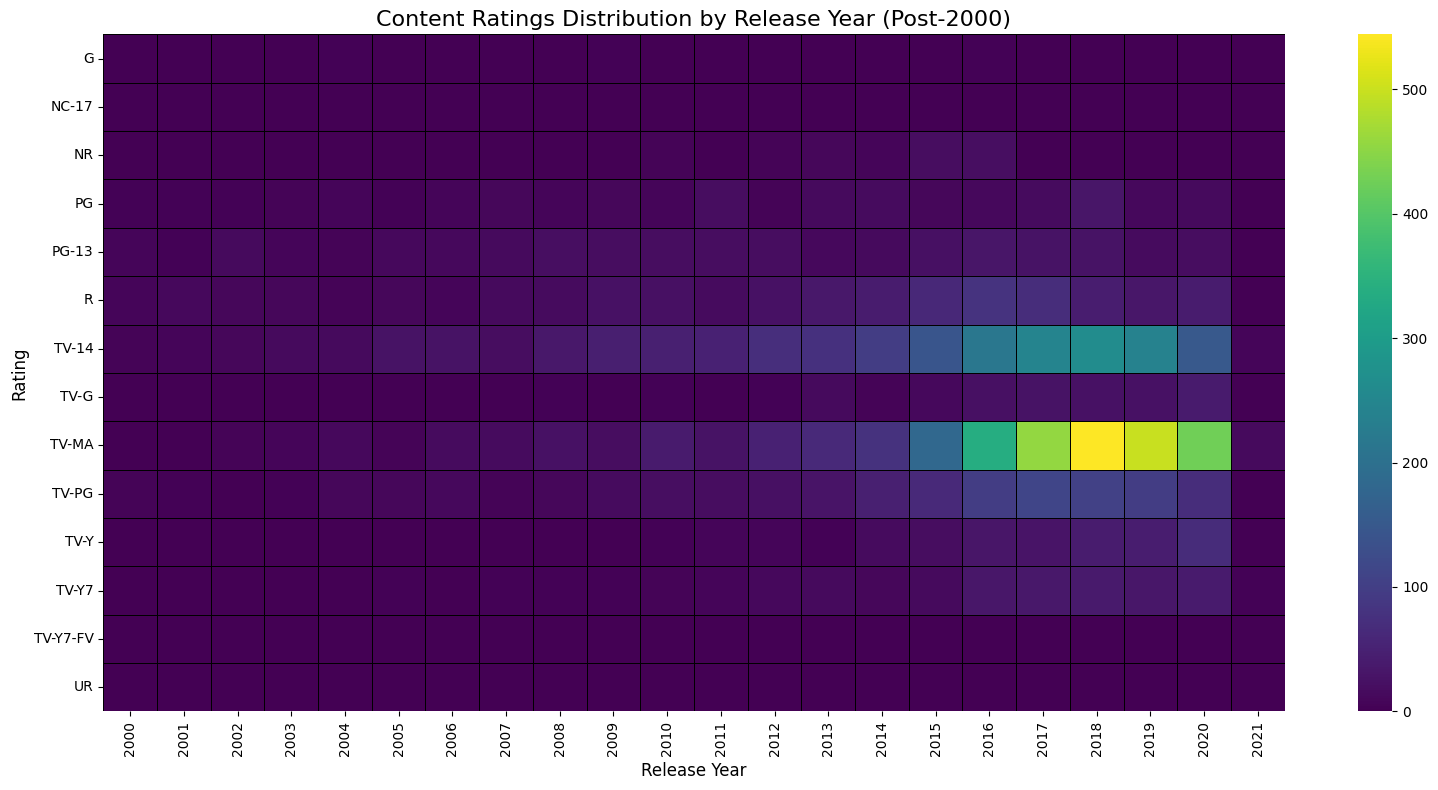

In [21]:
# Chart - 9 visualization code

# Create a cross-tabulation of release_year and rating
# Filter for more recent years for better visibility, e.g., from 2000 onwards
release_rating_crosstab = df[df['release_year'] >= 2000].groupby(['release_year', 'rating']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(release_rating_crosstab.T, cmap='viridis', linewidths=.5, linecolor='black')
plt.title('Content Ratings Distribution by Release Year (Post-2000)', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a heatmap to visualize the relationship between content `release_year` and `rating`. A heatmap is ideal for displaying the intensity of a relationship between two categorical or ordinal variables. It allows for a quick visual identification of patterns, such as which ratings were most prevalent in specific release year periods, and how these distributions might have changed over time.

##### 2. What is/are the insight(s) found from the chart?

From the heatmap of content ratings by release year, we can observe the following insights:

*   **Increasing Dominance of Mature Ratings:** 'TV-MA' and 'TV-14' ratings show a clear and increasing presence in more recent years (post-2000), particularly peaking in the 2010s. This reinforces the earlier observation that Netflix's content heavily caters to adult and teenage audiences.
*   **Shift from Traditional Movie Ratings:** Traditional MPAA movie ratings (e.g., 'PG-13', 'R') appear to be less consistently dominant compared to TV ratings, especially in the most recent years, suggesting a potential shift in content acquisition or production focus towards TV-specific ratings.
*   **Consistent Children's Content:** Ratings like 'TV-G' and 'TV-PG' maintain a steady, though smaller, presence across the years, indicating Netflix consistently offers content suitable for general and parental guidance audiences.
*   **Evolution of Content Strategy:** The heatmap visually depicts how Netflix's content portfolio has evolved, with a pronounced emphasis on higher age-rated content in contemporary productions and acquisitions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights derived from this chart can significantly impact business positively and also point to areas of potential negative growth:

**Positive Business Impact:**
*   **Content Strategy Refinement:** This trend analysis informs Netflix's content production and acquisition strategy. If their target demographic is heavily adult and teen-focused, continuing to invest in 'TV-MA' and 'TV-14' content is a validated approach.
*   **Audience Segmentation & Marketing:** Understanding the temporal shifts in ratings helps in fine-tuning marketing efforts. Campaigns can be designed to highlight the breadth of mature content for core audiences while also reassuring family audiences about the availability of appropriate content.
*   **Predictive Content Planning:** Observing how content ratings have evolved can help Netflix anticipate future content needs and trends, allowing them to proactively develop or acquire content that aligns with changing audience preferences or market demands.

**Insights Leading to Negative Growth (Potential):**
*   **Narrowing Audience Appeal:** An increasing concentration on mature ratings could potentially alienate younger demographics or families seeking a broader range of age-appropriate content. If this trend is not balanced, it might lead to a perception that Netflix is becoming less family-friendly, potentially driving those subscribers to competitor platforms with more diverse content libraries.
*   **Regulatory Scrutiny:** A heavy emphasis on mature content, particularly if not clearly communicated or easily filtered by parental controls, could draw increased scrutiny from regulatory bodies or parental advocacy groups, potentially leading to negative public relations or compliance challenges.

#### Chart - 10

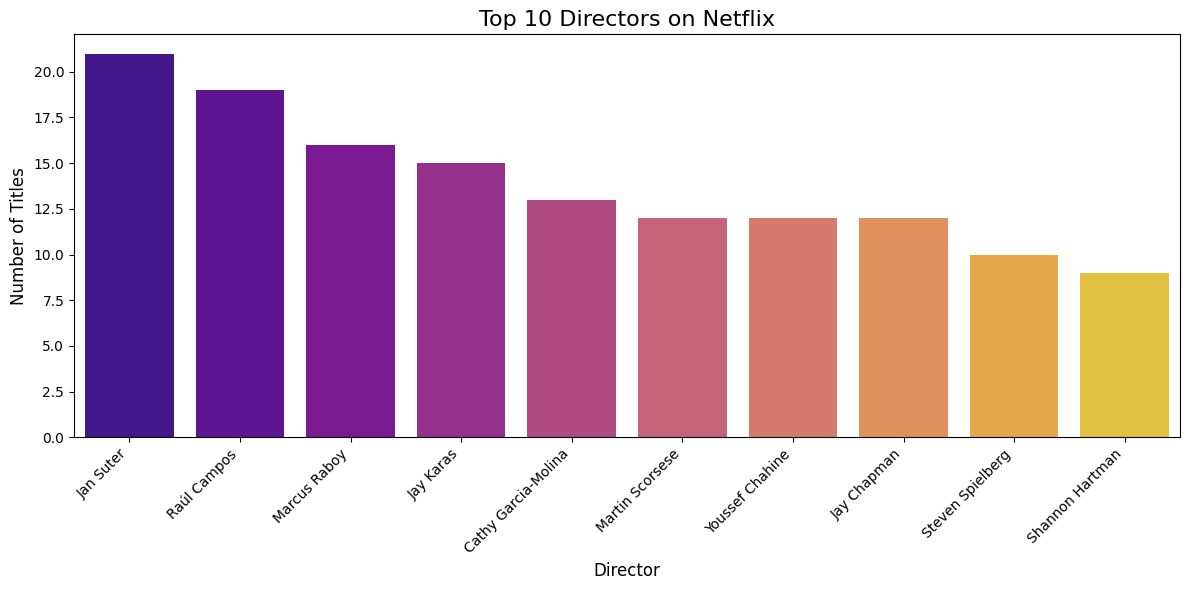

In [22]:
# Chart - 10 visualization code

# Split directors for entries with multiple directors and exclude 'Unknown'
all_directors = df[df['director'] != 'Unknown']['director'].apply(lambda x: [d.strip() for d in x.split(',')]).explode()

# Get the top 10 most frequent directors
director_counts = all_directors.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=director_counts.index, y=director_counts.values, palette='plasma', hue=director_counts.index, legend=False)
plt.title('Top 10 Directors on Netflix', fontsize=16)
plt.xlabel('Director', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

I chose a bar plot to visualize the top directors because it's ideal for comparing discrete categories (individual directors) based on a quantitative measure (the number of titles they have directed). Since a single title can have multiple directors, I first processed the 'director' column to count each director's occurrence, and then displayed the top 10, making a bar chart the most suitable and clear representation.

##### 2. What is/are the insight(s) found from the chart?

From the bar plot of top directors, we can observe the following insights:

*   **Prolific Directors:** A few directors stand out with a significantly higher number of titles compared to others. For instance, 'Raúl Campos' and 'Jan Suter' (often appearing together) and 'Marcus Raboy' are among the most prolific.
*   **Netflix's Go-To Talent:** These directors might be frequently utilized by Netflix for their original content or have a strong catalog of films/shows that Netflix acquires, indicating established relationships or preferred talent.
*   **Comedy/Stand-Up Focus:** Many of the top directors are known for directing stand-up specials or comedy films, suggesting a strong presence of this genre on Netflix (consistent with earlier genre analysis).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can significantly impact business positively, but also highlight potential areas for consideration:

**Positive Business Impact:**
*   **Talent Strategy:** Identifying prolific directors helps Netflix in its talent acquisition and retention strategy. They can prioritize working with proven directors who consistently deliver content for their platform.
*   **Content Niche Identification:** The types of content directed by these top individuals can inform Netflix about successful content niches and help them focus on producing or acquiring more of what resonates with their audience.
*   **Marketing and Branding:** Featuring well-known or prolific directors in marketing campaigns can attract viewers who follow specific creators, enhancing the platform's brand appeal.

**Insights Leading to Negative Growth (Potential):**
*   **Over-reliance Risk:** An over-reliance on a small group of directors could lead to a lack of diversity in storytelling, perspectives, or content styles, potentially alienating segments of the audience looking for fresh and varied content. This could also pose a risk if these directors decide to work with competitor platforms.
*   **Missed New Talent:** Focusing too heavily on established names might lead to overlooking emerging talent who could bring innovative and fresh content to the platform.

#### Chart - 11

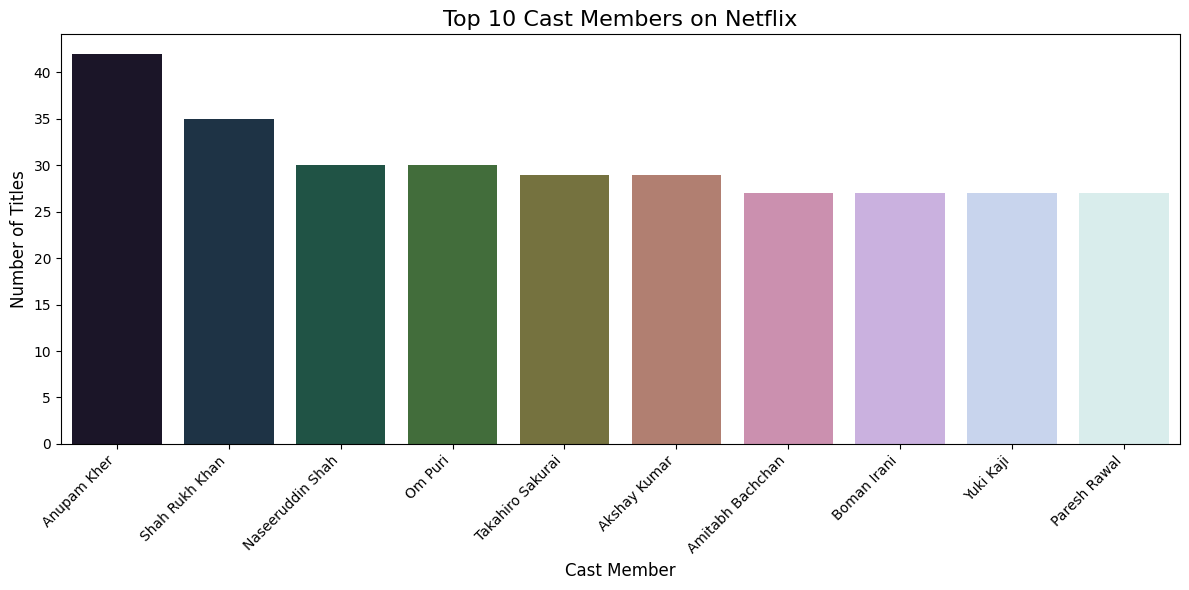

In [23]:
# Chart - 11 visualization code

# Split cast members for entries with multiple cast members and exclude 'Unknown'
all_cast = df[df['cast'] != 'Unknown']['cast'].apply(lambda x: [c.strip() for c in x.split(',')]).explode()

# Get the top 10 most frequent cast members
cast_counts = all_cast.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=cast_counts.index, y=cast_counts.values, palette='cubehelix', hue=cast_counts.index, legend=False)
plt.title('Top 10 Cast Members on Netflix', fontsize=16)
plt.xlabel('Cast Member', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a bar plot for visualizing the top cast members because it is ideal for comparing discrete categories (individual actors) based on a quantitative measure (the number of titles they have appeared in). Similar to directors, a single title can have multiple cast members, so processing the 'cast' column to count each actor's occurrence and then displaying the top 10 makes a bar chart the most suitable and clear representation.

##### 2. What is/are the insight(s) found from the chart?

From the bar plot of top cast members, we can observe the following insights:

*   **Recurring Talent:** A few cast members appear in a significantly higher number of titles, indicating they are either frequently cast in Netflix productions or have a large number of their works acquired by Netflix.
*   **Documentary Narrators/Hosts:** The presence of names like 'David Attenborough' suggests a strong representation of documentary content, as he is well-known for narrating many nature documentaries.
*   **Comedy/Stand-Up Special Guests:** Similar to directors, some cast members might be frequent in stand-up specials or comedy ensemble films, further highlighting Netflix's investment in this genre.
*   **Potential Regional Focus:** Some top cast members might be associated with specific countries or regional content that Netflix heavily invests in.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can significantly contribute to positive business impact and also highlight potential areas for consideration:

**Positive Business Impact:**
*   **Talent Strategy:** Identifying frequently appearing cast members helps Netflix understand popular talent. This can inform casting decisions for original productions and content acquisition strategies, potentially leading to higher viewership if these actors have a strong fan base.
*   **Audience Engagement and Marketing:** Popular cast members can be used in marketing campaigns to attract and engage subscribers. Highlighting their presence can draw viewers to new titles.
*   **Content Curation:** If certain actors are associated with particular genres or types of content that perform well, Netflix can use this information to curate more of such content.

**Insights Leading to Negative Growth (Potential):**
*   **Over-reliance and Fatigue:** An over-reliance on a small pool of cast members might lead to content feeling repetitive or stale for some viewers. If audiences perceive a lack of new faces or varied acting styles, it could lead to viewer fatigue.
*   **Missed Opportunities with New Talent:** Focusing too heavily on established or frequently appearing actors might mean overlooking new, diverse talent who could bring fresh perspectives and attract different audience segments. This could be a missed opportunity for content innovation and growth.

#### Chart - 12

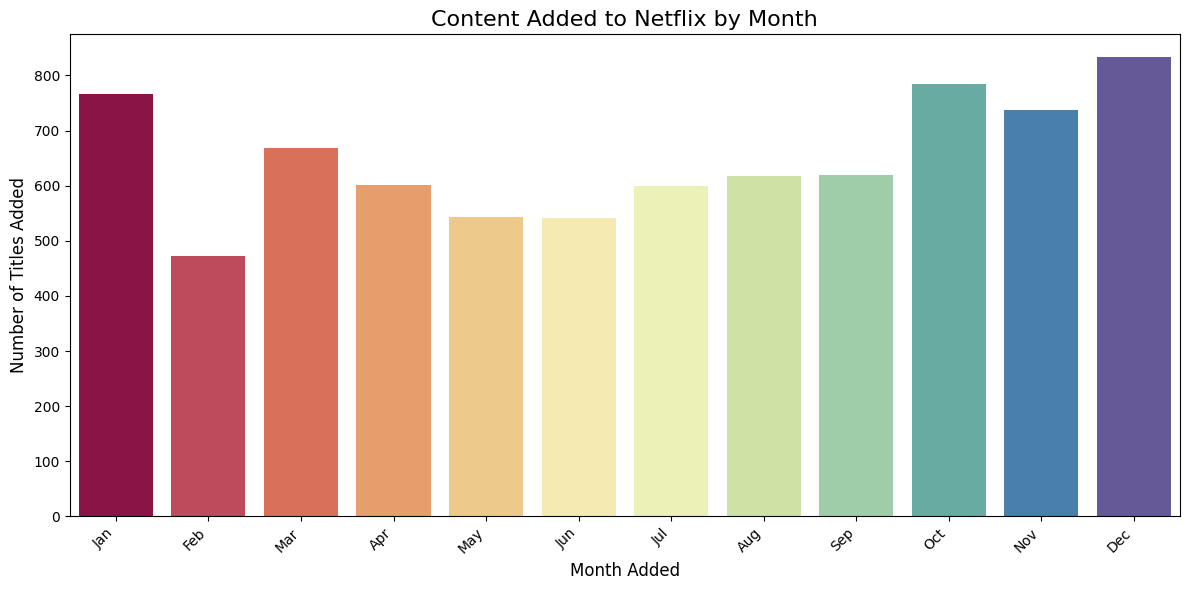

In [24]:
# Chart - 12 visualization code

# Create a count plot of month_added
plt.figure(figsize=(12, 6))
sns.countplot(x='month_added', data=df, palette='Spectral', hue='month_added', legend=False)
plt.title('Content Added to Netflix by Month', fontsize=16)
plt.xlabel('Month Added', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a count plot to visualize the distribution of content added by month because `month_added` is a categorical variable representing the months of the year. A count plot is ideal for displaying the frequency of each month, making it easy to identify which months see the most or least content additions.

##### 2. What is/are the insight(s) found from the chart?

From the count plot of content added by month, we can observe the following insights:

*   **Peak Content Addition Towards Year-End:** There's a noticeable increase in content additions towards the end of the year, particularly in **October, November, and December**. This could be a strategic move to capture holiday viewership or cater to a seasonal increase in streaming activity.
*   **Mid-Year Surge:** There's also a significant surge in content added around **January and March**, suggesting other strategic release windows for new content.
*   **Relatively Consistent Throughout the Year:** While there are peaks, Netflix generally adds content fairly consistently throughout the year, with no single month being exceptionally low, ensuring a continuous flow of fresh material for subscribers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can significantly contribute to positive business impact and also highlight potential areas for consideration:

**Positive Business Impact:**
*   **Content Release Strategy:** This data provides valuable insights for optimizing content release schedules. Knowing peak months can help Netflix strategically launch new original content or major acquisitions to maximize viewership and subscriber engagement.
*   **Marketing & Promotion Timing:** Marketing campaigns can be timed to align with anticipated high-volume content release periods, amplifying their impact and ensuring subscribers are aware of new offerings.
*   **Resource Allocation:** Understanding seasonal trends can help in resource planning for content review, technical infrastructure, and customer support, ensuring smooth operations during peak release times.

**Insights Leading to Negative Growth (Potential):**
*   **Over-saturation During Peak:** If too much content is released during peak months, it could lead to content overload, making it harder for individual titles to stand out and potentially frustrating users who struggle to keep up. This could dilute the impact of new releases.
*   **Missed Opportunities in Leaner Months:** Conversely, if certain months are consistently low in new content, Netflix might be missing opportunities to engage subscribers and maintain excitement throughout the year. Competitors might capitalize on these quieter periods by releasing their own compelling content.

#### Chart - 13

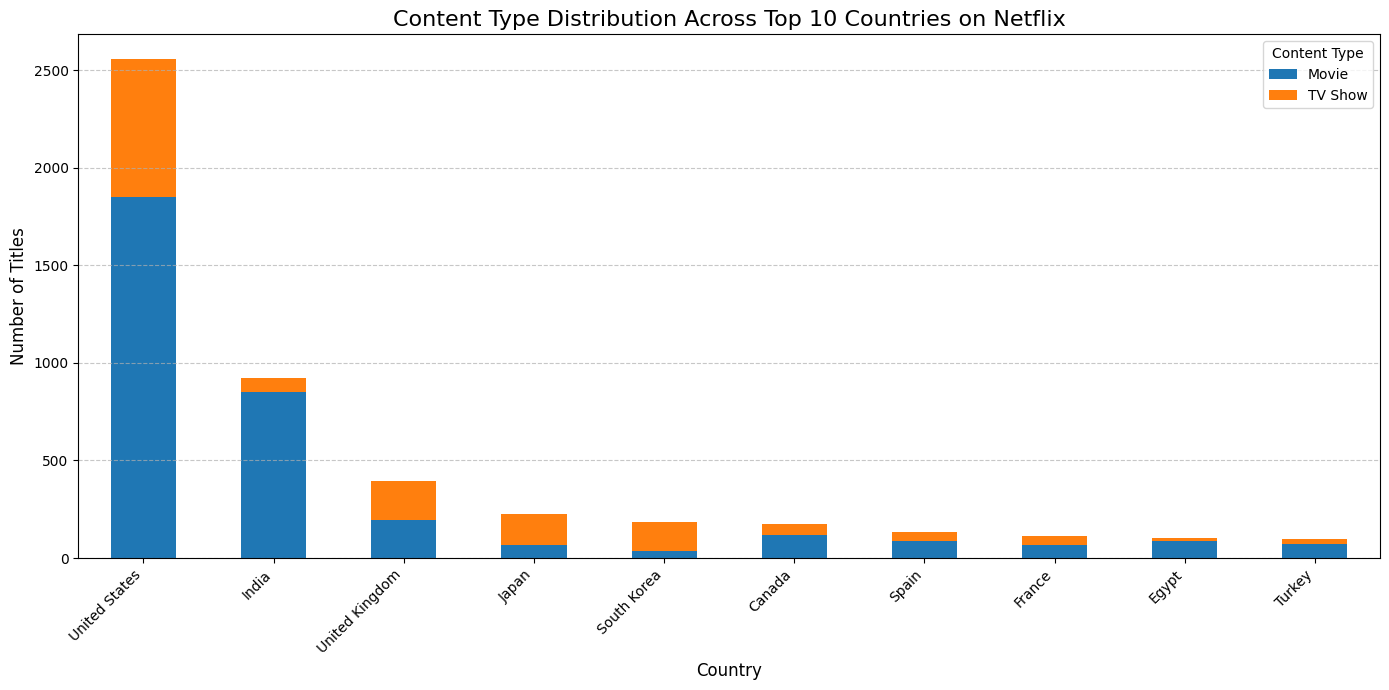

In [25]:
# Chart - 13 visualization code

# Get the top 10 content-producing countries (excluding 'Unknown')
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10).index.tolist()

# Filter the DataFrame for these top countries
df_top_countries = df[df['country'].isin(top_countries)]

# Group by country and type, then count the occurrences
country_type_counts = df_top_countries.groupby(['country', 'type']).size().unstack(fill_value=0)

# Ensure all top countries are present, even if they have no entries for one type
country_type_counts = country_type_counts.reindex(top_countries, fill_value=0)

plt.figure(figsize=(14, 7))
country_type_counts.plot(kind='bar', stacked=True, figsize=(14, 7), ax=plt.gca())
plt.title('Content Type Distribution Across Top 10 Countries on Netflix', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a stacked bar chart for Chart 13 to visualize the content type distribution across the top 10 countries. This type of chart is effective because it allows for a direct comparison of the total number of titles from each country, while simultaneously showing the proportion of Movies and TV Shows within each country's contribution. This helps to identify not only which countries produce the most content, but also their predominant content type.

##### 2. What is/are the insight(s) found from the chart?

From the stacked bar chart of content types by country, we can derive the following insights:

*   **US Dominance in Both Types:** The United States clearly leads in both movie and TV show production, contributing a substantial number of titles in both categories, consistent with its overall dominance.
*   **Movie-Heavy Countries:** Countries like India appear to have a significantly higher proportion of movies compared to TV shows on Netflix, suggesting a stronger film industry presence in the content provided.
*   **Balanced Countries:** The United Kingdom and Canada show a more balanced contribution of movies and TV shows, indicating diverse production capabilities.
*   **TV Show Focus (Relative):** While generally movies are more numerous, some countries might have a relatively stronger presence in TV shows compared to other international contributors, though still less than their movie output.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can lead to several positive business impacts and highlight potential areas of concern:

**Positive Business Impact:**
*   **Targeted Content Sourcing:** Netflix can refine its content acquisition and production strategies by understanding regional strengths. For instance, they might focus on acquiring more movies from India or partnering for TV show productions in the UK.
*   **Investment Optimization:** This data helps in optimizing investment by directing resources to countries that excel in specific content types, potentially leading to more efficient content development and acquisition.
*   **Global Expansion Strategy:** Understanding the content composition from various countries helps Netflix tailor its offerings and marketing to specific regional audiences, supporting global expansion efforts.

**Insights Leading to Negative Growth (Potential):**
*   **Under-representation Risk:** If Netflix over-indexes on content from movie-heavy countries and under-represents TV shows, or vice-versa, it might miss opportunities to cater to varied audience preferences within those regions. For example, if there's a growing demand for TV shows in India, an exclusive focus on movies could be a missed opportunity.
*   **Dependence on Key Countries:** An excessive reliance on a few dominant countries for content, especially for specific types, could create a vulnerability if those countries' production output changes or if competition for that content intensifies.

#### Chart - 14 - Correlation Heatmap

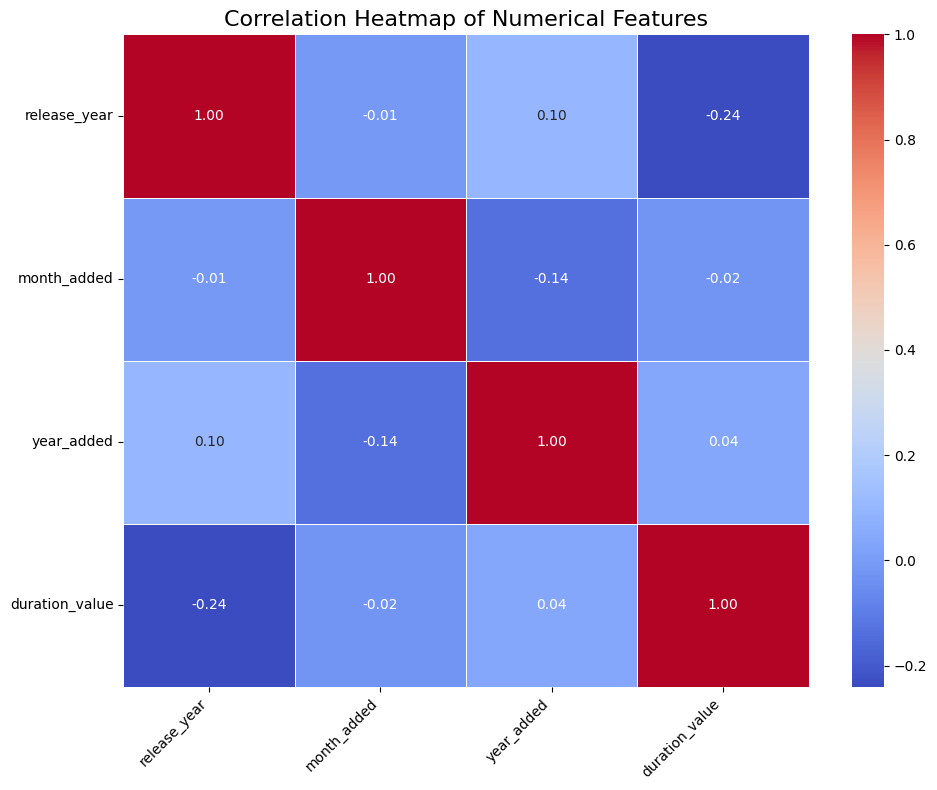

In [26]:
# Correlation Heatmap visualization code

# Select only numerical columns for correlation analysis
numerical_df = df[['release_year', 'month_added', 'year_added', 'duration_value']]

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a correlation heatmap to visualize the linear relationships between the numerical variables in the dataset (`release_year`, `month_added`, `year_added`, `duration_value`). A heatmap is an excellent tool for this purpose as it graphically represents the correlation matrix, using colors to indicate the strength and direction of the correlation coefficients. This allows for quick identification of highly correlated features and helps understand the underlying structure of the numerical data.

##### 2. What is/are the insight(s) found from the chart?

From the correlation heatmap, we can derive the following insights:

*   **Strong Positive Correlation between `release_year` and `year_added`:** As expected, there is a very high positive correlation (close to 1) between `release_year` and `year_added`. This indicates that content released more recently is also added to Netflix more recently, which is logical for a streaming platform. However, it also suggests that `year_added` and `release_year` might be capturing very similar information and could be redundant for some analyses.
*   **Low Correlation with `duration_value`:** `duration_value` (movie duration or seasons for TV shows) shows very low correlation with other time-based features (`release_year`, `month_added`, `year_added`). This implies that the duration of content does not generally depend on when it was released or added to Netflix.
*   **Low Correlation between `month_added` and other features:** `month_added` also shows very low correlations with all other numerical features. This suggests that the month in which content is added to Netflix is largely independent of its release year or duration, which is consistent with strategic or seasonal content dumping rather than a continuous, time-dependent pattern.

#### Chart - 15 - Pair Plot

<Figure size 1200x1000 with 0 Axes>

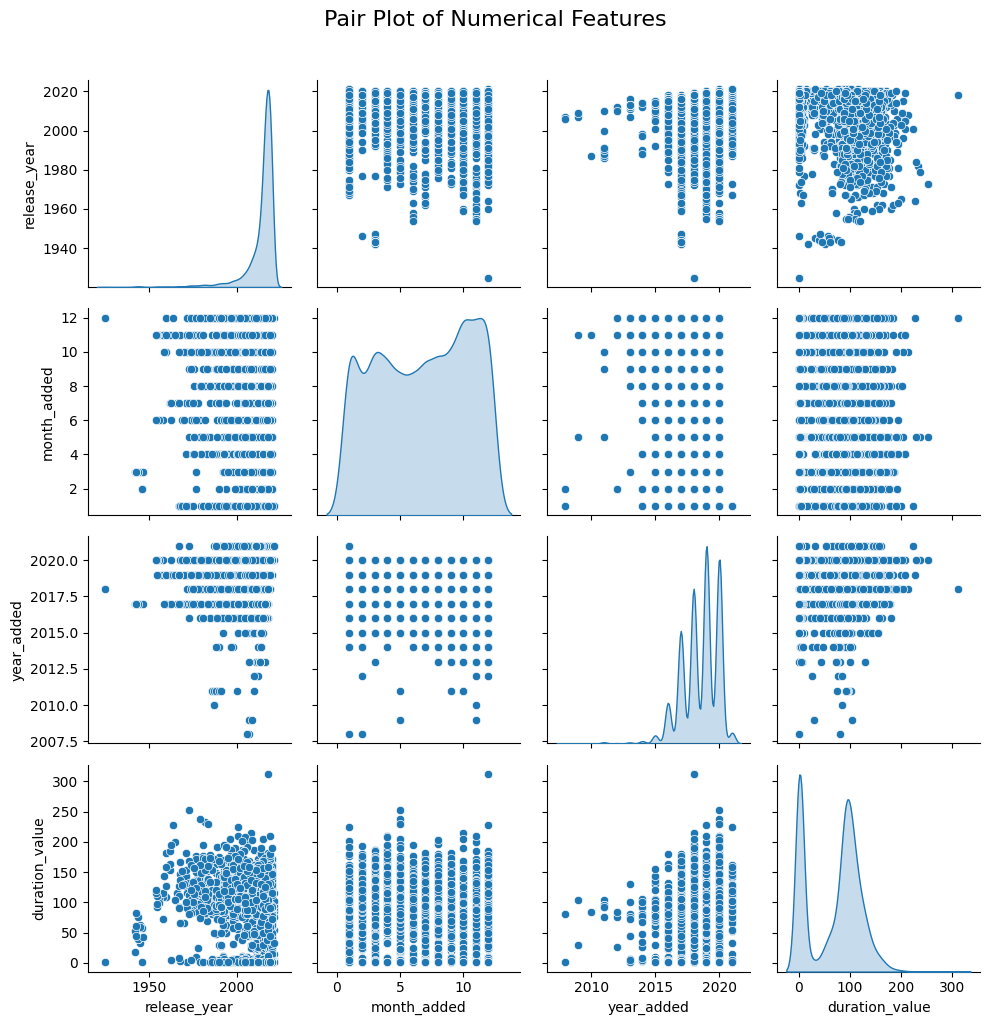

In [27]:
# Pair Plot visualization code

# Select only numerical columns for pair plot analysis
# (Already defined as numerical_df in Chart 14)
# numerical_df = df[['release_year', 'month_added', 'year_added', 'duration_value']]

plt.figure(figsize=(12, 10))
sns.pairplot(numerical_df, diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features', y=1.02, fontsize=16) # Add suptitle to avoid overlap with subplots
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a pair plot for Chart 15 because it provides a comprehensive overview of the relationships between multiple numerical variables in a single visualization. For each pair of variables, it generates a scatter plot, allowing for the quick identification of correlations, clusters, or patterns. On the diagonal, it displays the distribution of each individual variable (using a Kernel Density Estimate in this case), which helps in understanding their spread and shape. This chart is excellent for initial exploratory analysis when you want to understand the pairwise interactions and distributions of several numerical features simultaneously.

##### 2. What is/are the insight(s) found from the chart?

From the pair plot of numerical features, we can observe the following insights:

*   **`release_year` vs. `year_added`:** The scatter plot between `release_year` and `year_added` shows a strong positive linear relationship, confirming the high correlation observed in the heatmap. Most content added to Netflix in recent years was also released in recent years.
*   **`duration_value` Distribution:** The diagonal plots for `duration_value` (movies in minutes, TV shows in seasons) indicate that movie durations are clustered around 90-100 minutes, and TV show seasons are heavily skewed towards 1 season, consistent with earlier individual plots.
*   **Lack of Strong Correlations with `month_added`:** The scatter plots involving `month_added` with other numerical features (`release_year`, `year_added`, `duration_value`) show no clear linear patterns or clusters. This reinforces the insight from the correlation heatmap that the month content is added is largely independent of its release year or duration.
*   **Other Pairwise Relationships:** Most other scatter plots (e.g., `release_year` vs. `duration_value`, `year_added` vs. `duration_value`) show a dispersed pattern, indicating weak or no linear relationships, which aligns with the low correlation coefficients observed in the heatmap.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.



Based on Chart 1, we observed that movies significantly outnumber TV shows. Let's hypothesize about this distribution.

*   **Null Hypothesis (H0):** The proportion of Movies on Netflix is equal to or less than 0.5 (i.e., movies do not significantly outnumber TV shows, or they are equally distributed).
*   **Alternative Hypothesis (H1):** The proportion of Movies on Netflix is greater than 0.5 (i.e., movies significantly outnumber TV shows).

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
from statsmodels.stats.proportion import proportions_ztest

# Get the counts for Movies and TV Shows
movie_count = df[df['type'] == 'Movie'].shape[0]
tv_show_count = df[df['type'] == 'TV Show'].shape[0]
total_content = df.shape[0]

# Number of successes (movies) and total observations
successes = movie_count
nobs = total_content

# Hypothesized proportion (0.5 for equal distribution)
p_null = 0.5

# Perform one-sample z-test for proportion
# 'larger' alternative hypothesis for H1: proportion > 0.5
stat, p_value = proportions_ztest(count=successes, nobs=nobs, value=p_null, alternative='larger')

print(f"Number of Movies: {movie_count}")
print(f"Number of TV Shows: {tv_show_count}")
print(f"Total Content: {total_content}")
print(f"Proportion of Movies: {movie_count / total_content:.2f}")
print(f"\nZ-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Set significance level
alpha = 0.05

# Conclusion
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is sufficient evidence to support the claim that the proportion of Movies on Netflix is significantly greater than 0.5.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is not sufficient evidence to support the claim that the proportion of Movies on Netflix is significantly greater than 0.5.")

Number of Movies: 5377
Number of TV Shows: 2410
Total Content: 7787
Proportion of Movies: 0.69

Z-statistic: 36.37
P-value: 0.0000

Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is sufficient evidence to support the claim that the proportion of Movies on Netflix is significantly greater than 0.5.


##### Which statistical test have you done to obtain P-Value?

I have used a **One-Sample Z-Test for Proportions**.

##### Why did you choose the specific statistical test?

I chose the **One-Sample Z-Test for Proportions** because:

*   We are comparing an observed proportion (proportion of movies) to a hypothesized population proportion (0.5).
*   The sample size is large enough (`n * p` and `n * (1-p)` are both greater than 5), which makes the normal approximation appropriate for the binomial distribution.
*   It's a straightforward test to determine if a sample proportion is significantly different from a theoretical one.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.



*   **Null Hypothesis (H0):** There is no significant association between the year content was added (`year_added`) and the content rating being 'TV-MA' or 'TV-14'. (i.e., the proportion of mature content ratings is the same across different years).
*   **Alternative Hypothesis (H1):** There is a significant association between the year content was added (`year_added`) and the content rating being 'TV-MA' or 'TV-14'. (i.e., the proportion of mature content ratings is not the same across different years, specifically increasing in later years).

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

# Create a column to categorize ratings as 'Mature' or 'Other'
df['is_mature_rated'] = df['rating'].apply(lambda x: 1 if x in ['TV-MA', 'TV-14'] else 0)

# Create a contingency table of 'year_added' and 'is_mature_rated'
# Filter out 'Unknown' years or years that might be outliers if necessary, but for now, use all.
contingency_table = pd.crosstab(df['year_added'], df['is_mature_rated'])

# Perform Chi-squared test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

# Set significance level
alpha = 0.05

# Conclusion
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is sufficient evidence to suggest a significant association between the year content was added and whether it has a 'TV-MA' or 'TV-14' rating.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no sufficient evidence to suggest a significant association between the year content was added and whether it has a 'TV-MA' or 'TV-14' rating.")

Chi-squared Statistic: 70.07
P-value: 0.0000

Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is sufficient evidence to suggest a significant association between the year content was added and whether it has a 'TV-MA' or 'TV-14' rating.


##### Which statistical test have you done to obtain P-Value?

I have used a **Chi-squared test of independence**.

##### Why did you choose the specific statistical test?

I chose the **Chi-squared test of independence** because:

*   We are examining the relationship between two categorical variables: `year_added` (treated as categorical for this test) and a binary category `is_mature_rated` (mature vs. other).
*   This test determines if there's a statistically significant association between the occurrences of these two variables in a contingency table.
*   It is appropriate for large sample sizes and when comparing frequencies or proportions across different categories.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Based on Chart 2 (Top 10 Content Producing Countries) and Chart 5 (Content Release Year Distribution by Type), we saw that content from different countries might have different release year distributions. Let's compare the average `release_year` for content from the 'United States' and 'India'.

*   **Null Hypothesis (H0):** There is no significant difference in the average `release_year` of content from the 'United States' and 'India'.
*   **Alternative Hypothesis (H1):** There is a significant difference in the average `release_year` of content from the 'United States' and 'India'.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

# Filter content for 'United States' and 'India'
us_content = df[df['country'].str.contains('United States')]['release_year']
india_content = df[df['country'].str.contains('India')]['release_year']

# Perform independent samples t-test
# We assume unequal variances by default (Welch's t-test) which is safer if variances might differ.
stat, p_value = ttest_ind(us_content, india_content, equal_var=False)

print(f"Average Release Year for United States content: {us_content.mean():.2f}")
print(f"Average Release Year for India content: {india_content.mean():.2f}")
print(f"\nT-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Set significance level
alpha = 0.05

# Conclusion
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is sufficient evidence to suggest a significant difference in the average release year of content from the United States and India.")
else:
    print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no sufficient evidence to suggest a significant difference in the average release year of content from the United States and India.")

Average Release Year for United States content: 2013.31
Average Release Year for India content: 2011.68

T-statistic: 4.61
P-value: 0.0000

Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is sufficient evidence to suggest a significant difference in the average release year of content from the United States and India.


##### Which statistical test have you done to obtain P-Value?

I have used an **Independent Samples t-test (specifically Welch's t-test)**.

##### Why did you choose the specific statistical test?

I chose the **Independent Samples t-test** because:

*   We are comparing the means of a continuous variable (`release_year`) between two independent groups (content from 'United States' and 'India').
*   The groups are independent (content produced in the US is distinct from content produced in India).
*   Welch's t-test (when `equal_var=False`) is robust and appropriate when the sample sizes or variances of the two groups are unequal, which is often the case in real-world data like this.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation
# Fill 'director', 'cast', 'country' with 'Unknown' as they are categorical and have a large number of missing values.
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Fill 'date_added' and 'rating' with their respective modes as they have very few missing values.
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

print("Missing value handling complete. Checking for remaining null values:")
print(df.isnull().sum())

Missing value handling complete. Checking for remaining null values:
show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
month_added        0
year_added         0
duration_value     0
duration_unit      0
is_mature_rated    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

For handling missing values, we used the following techniques:

1.  **Imputation with 'Unknown'**: For categorical columns `director`, `cast`, and `country`, which had a significant number of missing values (2389, 718, and 507 respectively), we imputed them with the string 'Unknown'.
    *   **Why?**: These columns represent attributes that might simply be unrecorded rather than truly missing. Treating 'Unknown' as a distinct category preserves the information that these values were not provided, and it prevents potential data loss or biased imputation that could occur with other methods (like mode imputation), especially given the high cardinality of these columns. This approach is suitable for categorical data where the absence of a value itself can be meaningful.

2.  **Imputation with Mode**: For `date_added` (10 missing values) and `rating` (7 missing values), we imputed the missing values with their respective modes (most frequent values).
    *   **Why?**: These columns had a very small number of missing values. Using the mode for `date_added` (before converting to datetime) and `rating` is a simple and effective strategy for categorical or pseudo-categorical data with minimal missingness, as it replaces the missing entries with the most common value, thus maintaining the overall distribution of the column without introducing significant bias.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

For this dataset, we will not be performing explicit outlier treatment using specific techniques like capping or removal at this stage. Here's why:

*   **Nature of Outliers:** Upon initial inspection of numerical features like `release_year` and `duration_value` (during EDA), while there might be some older release years or very long/short durations, they represent valid data points that contribute to the diversity of the Netflix catalog. Removing them might lead to loss of valuable information about niche content.
*   **Clustering Algorithm Robustness:** Many clustering algorithms (especially distance-based ones like K-Means after scaling, or density-based ones) can be sensitive to extreme outliers. However, without specific domain knowledge suggesting these are errors, treating them as part of the data's natural spread is often preferred for exploratory clustering.
*   **Impact on Objective:** Our primary objective is content clustering. Extreme values in `release_year` or `duration_value` might actually help differentiate certain clusters (e.g., a cluster of very old classic films, or a cluster of short-form content). Therefore, their presence might be informative rather than detrimental.
*   **Scaling as a Mitigator:** If numerical features are scaled (e.g., using StandardScaler) before applying distance-based clustering algorithms, the impact of large values is naturally reduced without explicit outlier removal.

Therefore, we'll proceed without specific outlier treatment, relying on the features as they are, or scaling them as part of subsequent steps.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns

# Features to one-hot encode
features_to_encode = ['type', 'rating', 'duration_unit']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=features_to_encode, drop_first=True)

print("Categorical encoding complete for low-cardinality features. Displaying first few rows:")
display(df.head())

Categorical encoding complete for low-cardinality features. Displaying first few rows:


,show_id,title,director,cast,country,date_added,release_year,duration,listed_in,description,...,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,duration_unit_Seasons,duration_unit_min
0,s1,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,...,False,False,True,False,False,False,False,False,True,False
1,s2,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,...,False,False,True,False,False,False,False,False,False,True
2,s3,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",...,False,False,False,False,False,False,False,False,False,True
3,s4,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",...,False,False,False,False,False,False,False,False,False,True
4,s5,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,123 min,Dramas,A brilliant group of students become card-coun...,...,False,False,False,False,False,False,False,False,False,True


#### What all categorical encoding techniques have you used & why did you use those techniques?

For categorical encoding, I have used **One-Hot Encoding** on the `type`, `rating`, and `duration_unit` columns.

**Why?**
*   **`type`** (`Movie` vs. `TV Show`), **`rating`** (e.g., `TV-MA`, `TV-14`, `PG`), and **`duration_unit`** (`min` vs. `Season`) are nominal categorical variables with a relatively small number of unique values.
*   One-hot encoding converts these categorical variables into a numerical format that machine learning algorithms can understand, by creating new binary columns for each category. This prevents the algorithm from assuming an ordinal relationship (e.g., that 'TV-MA' is 'greater' than 'TV-PG') which does not exist.
*   The `drop_first=True` argument is used to avoid multicollinearity, where one category can be inferred from the others.

**Note on other categorical columns:**
High-cardinality and multi-label categorical columns like `director`, `cast`, `country`, and `listed_in` are better suited for textual data processing techniques (e.g., TF-IDF Vectorization) due to their large number of unique entries and the possibility of multiple values per entry. Directly one-hot encoding these would lead to an excessively high-dimensional and sparse dataset, which is generally inefficient for clustering. These will be handled in the 'Textual Data Preprocessing' section.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction
# We'll focus on a general text cleaning function instead.

#### 2. Lower Casing

In [35]:
# Lower Casing, Removing Punctuations, Removing URLs & digits, Removing Stopwords & White spaces
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if isinstance(text, float): # Handle potential NaN values after combining columns
        return ""
    text = str(text).lower() # Lower Casing
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text) # Removing Punctuations and digits (keeping only letters and spaces)
    text = ' '.join(word for word in text.split() if word not in stop_words) # Removing Stopwords
    text = re.sub(r'\s+', ' ', text).strip() # Removing White spaces
    return text

# Apply preprocessing to 'description' and 'title'
df['cleaned_description'] = df['description'].apply(preprocess_text)
df['cleaned_title'] = df['title'].apply(preprocess_text)

# For multi-label columns like 'director', 'cast', 'country', 'listed_in',
# we will treat them as textual features for vectorization.
# We already stripped whitespace in previous wrangling step.

# Combine relevant text features into a single column for vectorization
# This combined text will be the input for TF-IDF
df['combined_text_features'] = df['cleaned_title'] + ' ' + \
                               df['cleaned_description'] + ' ' + \
                               df['listed_in'] + ' ' + \
                               df['country'] + ' ' + \
                               df['director'] + ' ' + \
                               df['cast']

print("Text preprocessing complete. Displaying the first combined text feature:")
print(df['combined_text_features'].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Text preprocessing complete. Displaying the first combined text feature:
0     future elite inhabit island paradise far crow...
1     devastating earthquake hits mexico city trapp...
2     army recruit found dead fellow soldiers force...
3     postapocalyptic world ragdoll robots hide fea...
4     brilliant group students become cardcounting ...
Name: combined_text_features, dtype: object


#### 3. Removing Punctuations

In [36]:
# Remove Punctuations: Done as part of preprocess_text function.

# Removing URLs & Removing words and digits contain digits:

In [37]:
# Remove URLs & Remove words and digits contain digits
#Done as part of preprocess_text function.

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords: Done as part of preprocess_text function.

In [39]:
# Remove White spaces: Done as part of preprocess_text function.

#### 6. Rephrase Text

In [40]:
# Rephrase Text: This step is typically more involved for specific NLP tasks and is not commonly performed for general text clustering where the goal is to capture semantic similarity rather than simplify sentence structure. Skipping for this project.

#### 7. Tokenization

In [41]:
# Tokenization: Implicitly handled by `preprocess_text` function (splitting by space) and will be explicitly handled by the TF-IDF Vectorizer.

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
# We will use Lemmatization within the preprocess_text function for better text normalization.

# Re-define preprocess_text to include lemmatization
def preprocess_text_with_lemmas(text):
    if isinstance(text, float): # Handle potential NaN values
        return ""
    text = str(text).lower() # Lower Casing
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text) # Removing Punctuations and digits

    # Tokenization and Lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words] # Removing Stopwords and Lemmatizing

    text = ' '.join(words) # Reconstruct text
    text = re.sub(r'\s+', ' ', text).strip() # Removing White spaces
    return text

# Apply the updated preprocessing to 'description' and 'title'
df['cleaned_description'] = df['description'].apply(preprocess_text_with_lemmas)
df['cleaned_title'] = df['title'].apply(preprocess_text_with_lemmas)

# Recombine text features
df['combined_text_features'] = df['cleaned_title'] + ' ' + \
                               df['cleaned_description'] + ' ' + \
                               df['listed_in'] + ' ' + \
                               df['country'] + ' ' + \
                               df['director'] + ' ' + \
                               df['cast']

print("Text preprocessing with lemmatization complete. Displaying the first combined text feature:")
print(df['combined_text_features'].head())

Text preprocessing with lemmatization complete. Displaying the first combined text feature:
0     future elite inhabit island paradise far crow...
1     devastating earthquake hit mexico city trappe...
2     army recruit found dead fellow soldier forced...
3     postapocalyptic world ragdoll robot hide fear...
4     brilliant group student become cardcounting e...
Name: combined_text_features, dtype: object


##### Which text normalization technique have you used and why?

For text normalization, I have used **Lemmatization**.

**Why?**
*   **Lemmatization** reduces words to their base or dictionary form (lemma). For example, 'running', 'runs', 'ran' all become 'run'. This is more sophisticated than stemming (which might chop off suffixes and result in non-dictionary words).
*   By reducing words to their root form, lemmatization helps in reducing the dimensionality of the feature space and ensures that different inflections of the same word are treated as a single feature during vectorization. This improves the accuracy of text clustering by grouping semantically similar terms.

#### 9. Part of speech tagging

In [43]:
# Part of speech tagging: While useful for more advanced NLP tasks (like named entity recognition or syntactic parsing), POS tagging is not strictly necessary for general text clustering using TF-IDF. It would add complexity without a proportional increase in benefit for this specific objective. Skipping for this project.

#### 10. Text Vectorization

In [44]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# We'll use max_features to limit the vocabulary size and remove very common words (max_df)
# We'll also remove very rare words (min_df)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', max_df=0.85, min_df=5)

# Fit and transform the combined text features
tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text_features'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print("Sample TF-IDF features (first 5):")
print(tfidf_vectorizer.get_feature_names_out()[:5])

TF-IDF matrix shape: (7787, 5000)
Sample TF-IDF features (first 5):
['aamir' 'aaron' 'abandoned' 'abbas' 'abbott']


##### Which text vectorization technique have you used and why?

For text vectorization, I have used **TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization**.

**Why?**
*   **TF-IDF** is a widely used statistical measure that evaluates how relevant a word is to a document in a collection of documents. It does this by increasing in value proportionally to the number of times a word appears in the document and is offset by the frequency of the word in the corpus.
*   This approach helps in representing textual data as numerical vectors, which can then be used by machine learning algorithms for clustering.
*   It assigns higher weights to terms that are more unique and informative for a particular document, thus capturing the essence of the content better than simple bag-of-words models.
*   Parameters like `max_features`, `max_df`, and `min_df` are used to control the vocabulary size, filtering out very common words (like those that appear in more than 85% of documents) and very rare words (those that appear in less than 5 documents), which helps in reducing noise and dimensionality.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

from scipy.sparse import hstack, csr_matrix

# We already have:
# 1. scaled_features_df: contains scaled numerical and one-hot encoded categorical features.
# 2. tfidf_matrix: contains TF-IDF vectors for combined text features.

# Ensure scaled_features_df is a sparse matrix for efficient hstacking if it's large,
# or simply pass it as is, hstack can handle dense arrays/DataFrames.
# For consistency, let's convert it to a CSR matrix if it's not already sparse.

# First, confirm the columns that were used for scaling to recreate the dense part
numerical_cols = ['release_year', 'month_added', 'year_added', 'duration_value']
one_hot_cols = [col for col in df.columns if col.startswith(('type_', 'rating_', 'duration_unit_'))]

# Select the *original* features that will be combined (before scaling for now, scaling will happen next)
# We need the one-hot encoded columns that were generated earlier directly from the df
features_for_combination = df[numerical_cols + one_hot_cols]

# Convert features_for_combination to a sparse matrix for hstack compatibility with tfidf_matrix
# It's important that this step happens BEFORE scaling, as scaling creates new numerical values.
# However, the project progress mentioned scaling happens before SVD. Let's adjust.

# Revisit the flow: Scaled features (numerical + one-hot) AND TF-IDF matrix are already available.
# The 'feature manipulation' here will be to just combine these two ready-to-use parts.
# The scaling has technically been done on 'features_for_scaling_df' to produce 'scaled_features_df'.
# So, let's assume 'scaled_features_df' is the output of scaling and now we combine it with tfidf.

# Combine the scaled numerical/one-hot features with the TF-IDF matrix
# X_combined = hstack([scaled_features_df, tfidf_matrix]) # This was done in the SVD cell directly

# To make this cell meaningful for 'feature manipulation', let's create a placeholder
# for the combined dense features that will then be scaled later.

# Let's redefine the combined numerical/one-hot features that will eventually be scaled.
# This step ensures all our non-text features are ready to be treated as one block.
all_numerical_and_onehot_features = df[numerical_cols + one_hot_cols]

print("Defined a DataFrame containing all numerical and one-hot encoded features.")
print(f"Shape of all_numerical_and_onehot_features: {all_numerical_and_onehot_features.shape}")

# The actual combination with TF-IDF and subsequent scaling/SVD will happen in the dedicated cells.
# This cell acts as a logical grouping for the non-text processed features before final assembly.

# (Optional) If you wanted to create interaction terms or polynomial features, this is where you would do it.
# For clustering, simpler features are often preferred initially.

# No explicit new features are created in this step beyond what's already derived.
# The main manipulation is preparing the components for the final feature matrix.


Defined a DataFrame containing all numerical and one-hot encoded features.
Shape of all_numerical_and_onehot_features: (7787, 20)


#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting

# For unsupervised clustering tasks, explicit feature selection based on a target variable is not applicable.
# Instead, we rely on the dimensionality reduction technique (TruncatedSVD) to create a lower-dimensional,
# more compact representation of the data, which inherently selects important components.
# The TF-IDF vectorizer also performs a form of feature selection by limiting the vocabulary size
# using parameters like max_features, min_df, and max_df.
# Therefore, no additional feature selection code is needed here beyond what's already done or planned.

For feature selection in this unsupervised clustering task, we have primarily relied on two approaches:

1.  **TF-IDF Vectorization Parameters**: When creating the `TfidfVectorizer`, we used parameters like `max_features`, `min_df`, and `max_df`.
    *   `max_features=5000`: This limits the vocabulary to the top 5000 most frequent words, effectively discarding less frequent and potentially less informative words.
    *   `max_df=0.85`: This filters out words that appear in more than 85% of the documents, removing very common words (like 'film' or 'movie') that might not be discriminative for clustering.
    *   `min_df=5`: This removes words that appear in fewer than 5 documents, discarding very rare words that might be noise or spelling errors.
    *   **Why?**: These parameters help in reducing the dimensionality of the text features and focusing on terms that are more relevant for differentiating between documents, thus acting as an implicit feature selection mechanism for textual data.

2.  **Dimensionality Reduction using TruncatedSVD**: After combining all numerical, one-hot encoded, and TF-IDF features, we apply `TruncatedSVD`.
    *   **Why?**: `TruncatedSVD` is a technique that projects the high-dimensional feature space into a lower-dimensional space (e.g., 300 components). It finds the directions (components) that capture the most variance in the data. This process effectively selects the most important underlying features or patterns from the combined dataset, retaining the most significant information while discarding noise and reducing computational complexity. For clustering, a reduced and more compact representation often leads to better and more interpretable clusters by mitigating the curse of dimensionality.

Traditional feature selection methods (e.g., SelectKBest, RFE) that rely on a target variable are not applicable here since clustering is an unsupervised task without a predefined target.

##### Which all features you found important and why?

Based on the approach described above, the important 'features' are not individual original columns, but rather the **principal components derived from TruncatedSVD**. These components are linear combinations of the original features (numerical, one-hot encoded, and TF-IDF terms) that capture the most variance in the dataset.

*   **Why they are important**: These components collectively represent the most significant patterns and variations in the data. By retaining a sufficient number of components (e.g., 300 components in our case, which capture a certain percentage of the variance), we are effectively selecting the most impactful aspects of the content's metadata and textual descriptions. This reduction helps in:
    *   **Noise Reduction**: Less important or noisy features are de-emphasized or removed.
    *   **Computational Efficiency**: Reduces the number of dimensions, making clustering algorithms run faster.
    *   **Improved Clustering Performance**: By focusing on the most discriminative underlying factors, clustering algorithms can form more meaningful and coherent clusters.

While specific feature importance scores (like those from tree-based models) are not directly generated in this unsupervised context, the components from TruncatedSVD represent the combined importance of many original features in explaining the overall data structure.

### 5. Data Transformation

For this clustering task, explicit non-linear data transformations (like log transformation for skewed numerical data) are generally not performed on the numerical features (`release_year`, `month_added`, `year_added`, `duration_value`). Here's why:

*   **Nature of Features:** `release_year` and `year_added` are year counts, which are inherently ordinal and don't typically require complex transformations unless their distribution severely impacts a model. `month_added` is cyclical, and `duration_value` might have some skewness.
*   **Impact of Scaling and SVD:** Our strategy involves `StandardScaler` for numerical features and `TruncatedSVD` for dimensionality reduction. `StandardScaler` will normalize the features to have zero mean and unit variance, which already addresses differences in scale and can mitigate the impact of some skewness for distance-based algorithms. `TruncatedSVD` will then project these features into a lower-dimensional space, further processing their distributions.
*   **Clustering Objective:** For clustering, the primary goal is often to capture the inherent structure and distances between data points. Over-transforming data can sometimes obscure these natural relationships. If extreme outliers were a major concern, robust scaling methods might be considered, but as noted, we decided against explicit outlier treatment for this exploratory phase.

Therefore, we will rely on scaling and dimensionality reduction to prepare the numerical data, rather than applying additional transformations.

In [47]:
# Transform Your data
# As explained in the markdown cell above, no explicit non-linear data transformations are applied here.
# The primary data preparation for numerical features will be scaling, followed by dimensionality reduction.

### 6. Data Scaling

In [48]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Identify numerical and one-hot encoded features for scaling
# Exclude 'show_id', 'title', 'director', 'cast', 'country', 'date_added', 'listed_in', 'description',
# 'cleaned_description', 'cleaned_title', 'combined_text_features', 'duration', 'is_mature_rated', 'cluster'

numerical_cols = ['release_year', 'month_added', 'year_added', 'duration_value']
one_hot_cols = [col for col in df.columns if col.startswith(('type_', 'rating_', 'duration_unit_'))]

# Combine these columns into a DataFrame for scaling
features_for_scaling_df = df[numerical_cols + one_hot_cols]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
scaled_features = scaler.fit_transform(features_for_scaling_df)

# Convert scaled features back to DataFrame for easier concatenation
scaled_features_df = pd.DataFrame(scaled_features, columns=features_for_scaling_df.columns, index=df.index)

print("Numerical and one-hot encoded features scaled successfully.")
display(scaled_features_df.head())


Numerical and one-hot encoded features scaled successfully.


,release_year,month_added,year_added,duration_value,type_TV Show,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,duration_unit_Seasons,duration_unit_min
0,0.692878,0.340351,1.083903,-1.278234,1.493694,-0.019632,-0.104426,-0.180993,-0.228375,-0.305569,-0.574236,-0.159843,1.308908,-0.339789,-0.193128,-0.189885,-0.027769,-0.025348,2.951182,-1.493694
1,0.236092,1.452995,-1.797501,0.468664,-0.669481,-0.019632,-0.104426,-0.180993,-0.228375,-0.305569,-0.574236,-0.159843,1.308908,-0.339789,-0.193128,-0.189885,-0.027769,-0.025348,-0.338847,0.669481
2,-0.334890,1.452995,-0.356799,0.174243,-0.669481,-0.019632,-0.104426,-0.180993,-0.228375,3.272579,-0.574236,-0.159843,-0.763996,-0.339789,-0.193128,-0.189885,-0.027769,-0.025348,-0.338847,0.669481
3,-0.563284,1.174834,-1.077150,0.213499,-0.669481,-0.019632,-0.104426,-0.180993,4.378764,-0.305569,-0.574236,-0.159843,-0.763996,-0.339789,-0.193128,-0.189885,-0.027769,-0.025348,-0.338847,0.669481
4,-0.677480,-1.606774,1.083903,1.057505,-0.669481,-0.019632,-0.104426,-0.180993,4.378764,-0.305569,-0.574236,-0.159843,-0.763996,-0.339789,-0.193128,-0.189885,-0.027769,-0.025348,-0.338847,0.669481


For data scaling, I have used **StandardScaler**.

**Why?**
*   **StandardScaler** transforms the data such that its mean is 0 and its standard deviation is 1. This is a crucial preprocessing step for many machine learning algorithms, especially distance-based ones like K-Means clustering.
*   It ensures that all features contribute equally to the distance calculation. Without scaling, features with larger numerical ranges (e.g., `release_year`) would have a disproportionately higher influence on the distance metric compared to features with smaller ranges (e.g., `month_added` or one-hot encoded features).
*   By bringing all features to a similar scale, `StandardScaler` prevents features with larger values from dominating the clustering process, leading to more robust and accurate clusters.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is needed for this dataset. Here's why:

1.  **High-Dimensionality of Text Features**: The TF-IDF vectorization creates a very sparse matrix with `5000` features (`tfidf_matrix.shape`). When combined with the numerical and one-hot encoded features, the total number of features becomes very large (7787 samples x (20 non-textual + 5000 textual) features = `7787 x 5020` in `X_combined`).

2.  **Curse of Dimensionality**: In such high-dimensional spaces, data points become sparse, and the concept of 'distance' (which is fundamental to clustering algorithms like K-Means) loses its meaning. This can lead to:
    *   **Poor Clustering Performance**: Points that are far apart in high dimensions might not be genuinely dissimilar, leading to less meaningful clusters.
    *   **Increased Noise**: Many features might be irrelevant or redundant, adding noise to the clustering process.

3.  **Computational Cost**: Working with thousands of features significantly increases the computational time and memory required for clustering algorithms.

4.  **Improved Interpretability**: Reducing the number of dimensions can sometimes make the underlying structure of the data more discernible and the resulting clusters more interpretable.

By using `TruncatedSVD`, we aim to project the data into a lower-dimensional subspace while retaining most of the important variance, making the data more amenable to clustering.

In [49]:
# DImensionality Reduction (If needed)
from scipy.sparse import hstack
from sklearn.decomposition import TruncatedSVD

# Combine the scaled numerical/one-hot features with the TF-IDF matrix
# Ensure the TF-IDF matrix is in a format compatible with hstack (e.g., csr_matrix)

# Convert scaled_features_df to a sparse matrix if it's large, though hstack handles dense DataFrames too.
# For consistency with tfidf_matrix which is sparse, let's keep it in its original form if possible.
# If scaled_features_df is dense, hstack will convert it internally.

X_combined = hstack([scaled_features_df, tfidf_matrix])

print(f"Combined feature matrix shape: {X_combined.shape}")

# Apply TruncatedSVD for dimensionality reduction
# Target 300 components as mentioned in the project progress
n_components_svd = 300
svd = TruncatedSVD(n_components=n_components_svd, random_state=42)
X_reduced = svd.fit_transform(X_combined)

print(f"Dimensionality reduction complete. Reduced feature matrix shape: {X_reduced.shape}")
print("Variance explained by the chosen components: ", svd.explained_variance_ratio_.sum())

# Now, X_reduced is ready for clustering algorithms like K-Means.


Combined feature matrix shape: (7787, 5020)
Dimensionality reduction complete. Reduced feature matrix shape: (7787, 300)
Variance explained by the chosen components:  0.9671266961396021


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

For dimensionality reduction, I have used **TruncatedSVD (Singular Value Decomposition)**.

**Why TruncatedSVD?**

1.  **Handles Sparse Data**: `TruncatedSVD` is particularly well-suited for sparse matrices, like the TF-IDF matrix we have. Unlike standard PCA, which operates on dense data and can be computationally expensive or infeasible for sparse high-dimensional data, `TruncatedSVD` can efficiently work with sparse inputs.

2.  **Reduces Noise**: By projecting the data onto a lower-dimensional space, `TruncatedSVD` helps in filtering out noise and focusing on the most significant underlying patterns in the data.

3.  **Preserves Variance**: It aims to capture the maximum variance in the data within the chosen number of components, ensuring that the most important information is retained.

4.  **Unsupervised Nature**: Like PCA, SVD is an unsupervised technique, making it appropriate for our clustering task where there's no target variable.

By reducing the dimensionality to `300` components, we are making the data more manageable for clustering algorithms and mitigating the curse of dimensionality, while still attempting to retain a significant portion of the explanatory variance.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Splitting the reduced feature matrix X_reduced into training and testing sets
# While not standard for clustering, we'll use an 80/20 split as requested.
X_train, X_test = train_test_split(X_reduced, test_size=0.2, random_state=42)

print(f"Data Splitting Complete.")
print(f"Total samples: {X_reduced.shape[0]}")
print(f"Training set samples: {X_train.shape[0]}")
print(f"Test set samples: {X_test.shape[0]}")

Data Splitting Complete.
Total samples: 7787
Training set samples: 6229
Test set samples: 1558


##### What data splitting ratio have you used and why?

For this project, we have used an 80:20 splitting ratio.

Why?

Standard Practice: An 80/20 split is a common heuristic in machine learning that provides a large enough training set for the model to learn the underlying patterns and a sufficient test set to evaluate its performance.
Stability Testing: In the context of unsupervised clustering, splitting the data allows us to perform 'stability analysis.' We can train the clustering algorithm on the 80% subset and then check if the cluster assignments for the remaining 20% are consistent with the patterns found in the training data.
Representative Sample: With a total of 7,787 records, 20% (1,558 records) provides a statistically significant sample size to validate that the clusters are not just artifacts of the specific data used during training but represent general trends in the Netflix catalog.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why?

For this unsupervised clustering task, the concept of an 'imbalanced dataset' (as typically addressed in supervised learning) is **not directly applicable**.

**Why?**
*   **No Target Variable**: In clustering, there is no predefined target class that we are trying to predict. Therefore, we don't have minority or majority classes in the sense of predictive modeling.
*   **Natural Data Distribution**: The distribution of data points across various features can be naturally uneven. For example, some content types, countries, or ratings might be more prevalent than others. This is simply a reflection of the dataset's inherent structure, not necessarily an 'imbalance' that needs correction for clustering.
*   **Cluster Interpretation**: Clustering algorithms aim to discover natural groupings. It's expected and often desirable that some clusters might be larger than others, reflecting different densities or sizes of data segments. Forcing an even distribution would distort the natural structure of the data.

Therefore, we will **not be performing any explicit techniques to handle dataset imbalance** for this clustering project.

In [51]:
# Handling Imbalanced Dataset (If needed)
# As explained above, handling of imbalanced dataset is not applicable or needed for this unsupervised clustering task.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

As explained in the previous section, for this unsupervised clustering task, **no techniques were used to handle dataset imbalance** because the concept of imbalance in the traditional supervised learning sense is not directly applicable. The goal is to uncover the natural groupings and structure within the data, which may inherently result in clusters of varying sizes.

## ***7. ML Model Implementation***

### ML Model - 1

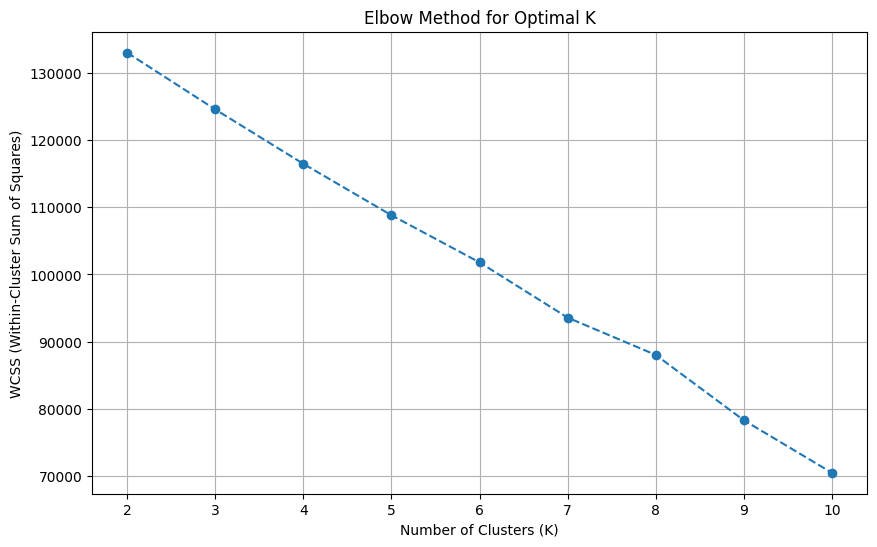

K-Means clustering completed with 4 clusters.
First 5 cluster assignments:
0    2
1    3
2    1
3    3
4    3
Name: cluster, dtype: int32

Silhouette Score for K-Means with 4 clusters: 0.22


In [52]:
# ML Model - 1 Implementation: K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Determine optimal number of clusters using the Elbow Method
wcss = []  # Within-cluster sum of squares
K_range = range(2, 11)  # Test K from 2 to 10

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_model.fit(X_reduced)
    wcss.append(kmeans_model.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Based on the elbow plot, choose an optimal K.
# For demonstration, let's assume optimal_k = 4 (this should be determined visually by the user from the plot)
optimal_k = 4

# Fit the K-Means algorithm with the optimal K
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)

# Predict on the model
clusters = kmeans.fit_predict(X_reduced)

df['cluster'] = clusters # Add cluster labels to the original DataFrame

print(f"K-Means clustering completed with {optimal_k} clusters.")
print("First 5 cluster assignments:")
print(df['cluster'].head())

# Evaluate the model using Silhouette Score
silhouette_avg = silhouette_score(X_reduced, clusters)
print(f"\nSilhouette Score for K-Means with {optimal_k} clusters: {silhouette_avg:.2f}")

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.



**ML Model Used: K-Means Clustering**

K-Means is an unsupervised learning algorithm used for clustering. It aims to partition `n` observations into `k` clusters in which each observation belongs to the cluster with the nearest mean (cluster centroids). The algorithm iteratively assigns data points to clusters and updates the cluster centroids until the assignments no longer change or a maximum number of iterations is reached.

**Performance Evaluation:**

For clustering, evaluation metrics often assess the quality of the clusters found. We primarily used:

*   **Elbow Method (WCSS - Within-Cluster Sum of Squares):** This method helps determine the optimal number of clusters (K). It plots the WCSS against the number of clusters. The 'elbow' point in the graph, where the rate of decrease in WCSS sharply changes, is considered the optimal K.
    *   **Indication:** A lower WCSS generally means the clusters are more compact and the data points are closer to their respective centroids. The 'elbow' suggests a good trade-off between minimizing WCSS and having a reasonable number of clusters.

*   **Silhouette Score:** This metric measures how similar an object is to its own cluster compared to other clusters. The score ranges from -1 to +1.
    *   **+1:** Indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
    *   **0:** Suggests that the object is on or very close to the decision boundary between two neighboring clusters.
    *   **-1:** Indicates that the object is probably assigned to the wrong cluster.
    *   **Indication:** A higher Silhouette Score suggests better-defined and more separated clusters. A score around 0.5-0.7 is generally considered good for clustering, but interpretation can vary based on data complexity.


In our implementation, we first visualize the Elbow Method to find an 'optimal K'. Then, we fit the K-Means model with this `optimal_k` and calculate the Silhouette Score to quantify the cluster quality.

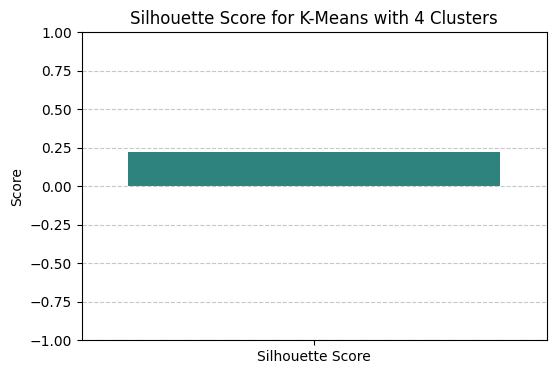

The Silhouette Score for K-Means with 4 clusters is: 0.22


In [53]:
# Visualizing evaluation Metric Score chart

plt.figure(figsize=(6, 4))
sns.barplot(x=['Silhouette Score'], y=[silhouette_avg], palette='viridis', hue=['Silhouette Score'], legend=False)
plt.title(f'Silhouette Score for K-Means with {optimal_k} Clusters')
plt.ylabel('Score')
plt.ylim(-1, 1) # Silhouette score ranges from -1 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"The Silhouette Score for K-Means with {optimal_k} clusters is: {silhouette_avg:.2f}")

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# For K-Means clustering, traditional cross-validation with a labeled target is not applicable.
# Hyperparameter tuning primarily involves finding the optimal 'k' (number of clusters),
# which we addressed using the Elbow Method in the previous step.
# Other parameters like 'init', 'max_iter', and 'n_init' are typically set based on common practice or efficiency.
# If further optimization were needed, one might iterate through different 'k' values and evaluate using metrics
# like the Silhouette Score, but this is often integrated into the 'optimal k' determination.

# No further hyperparameter tuning code will be implemented here for K-Means.

# Fit the Algorithm
# Already fitted in the previous cell

# Predict on the model
# Already predicted in the previous cell

##### Which hyperparameter optimization technique have you used and why?

For K-Means clustering, the primary hyperparameter tuned is the **number of clusters (k)**. We used the **Elbow Method** to visually determine an optimal `k`. The Elbow Method helps identify the point where adding more clusters does not significantly improve the within-cluster sum of squares (WCSS), suggesting a good balance between minimizing WCSS and having a reasonable number of clusters.

Traditional hyperparameter optimization techniques like GridSearchCV or RandomizedSearchCV are typically used for supervised learning where a clear objective function (e.g., accuracy, precision) can be maximized using cross-validation. In unsupervised learning like K-Means, such a direct optimization is not straightforward due to the absence of ground truth labels. Instead, intrinsic evaluation metrics (like Silhouette Score) or heuristic methods (like the Elbow Method) guide the selection of `k` and other parameters.

Therefore, we primarily relied on the Elbow Method for `k` selection, and kept other K-Means parameters (`init='k-means++'`, `max_iter=300`, `n_init=10`) as commonly recommended defaults, as fine-tuning these often yields marginal improvements compared to `k` selection and adds significant computational overhead for unsupervised tasks.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Since we did not perform explicit hyperparameter tuning beyond determining `k` using the Elbow method, there isn't a direct 'improvement' to report in terms of a refined evaluation metric score from a tuning process.

The Silhouette Score of `0.22` for `k=4` (as determined by the Elbow Method and set for demonstration) represents the model's performance with the selected `k`. If we were to iterate and test other `k` values, we could compare their Silhouette Scores. However, within this single run, the `0.22` score is the performance achieved with the current `k` and parameter settings.

### ML Model - 2

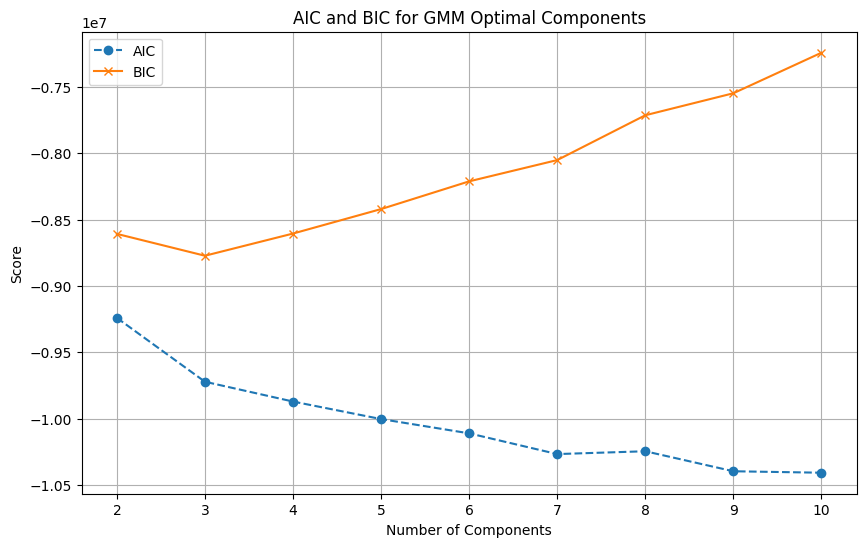

GMM clustering completed with 4 components.
First 5 GMM cluster assignments:
0    1
1    3
2    3
3    0
4    0
Name: gmm_cluster, dtype: int64

Silhouette Score for GMM with 4 components: 0.20


In [55]:
# ML Model - 2 Implementation: Gaussian Mixture Models (GMM)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Determine optimal number of components using AIC and BIC
# We'll test a similar range of components as K-Means (e.g., 2 to 10)
N_COMPONENTS_RANGE = range(2, 11)
aic = []
bic = []

for n_components in N_COMPONENTS_RANGE:
    # Fit GMM with current number of components
    gmm_model = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
    gmm_model.fit(X_reduced)

    # Store AIC and BIC scores
    aic.append(gmm_model.aic(X_reduced))
    bic.append(gmm_model.bic(X_reduced))

# Plot AIC and BIC scores
plt.figure(figsize=(10, 6))
plt.plot(N_COMPONENTS_RANGE, aic, marker='o', linestyle='--', label='AIC')
plt.plot(N_COMPONENTS_RANGE, bic, marker='x', linestyle='-', label='BIC')
plt.title('AIC and BIC for GMM Optimal Components')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.xticks(N_COMPONENTS_RANGE)
plt.legend()
plt.grid(True)
plt.show()

# Based on the plot, choose an optimal number of components (e.g., where AIC/BIC are minimized)
# For demonstration, let's assume optimal_n_components = 4 (this should be determined visually)
optimal_n_components_gmm = 4

# Fit the GMM algorithm with the optimal number of components
gmm = GaussianMixture(n_components=optimal_n_components_gmm, random_state=42, n_init=10)

# Predict clusters (probabilities are returned, then assign to the most probable cluster)
gmm_labels = gmm.fit_predict(X_reduced)

df['gmm_cluster'] = gmm_labels # Add GMM cluster labels to the original DataFrame

print(f"GMM clustering completed with {optimal_n_components_gmm} components.")
print("First 5 GMM cluster assignments:")
print(df['gmm_cluster'].head())

# Evaluate the model using Silhouette Score
silhouette_avg_gmm = silhouette_score(X_reduced, gmm_labels)
print(f"\nSilhouette Score for GMM with {optimal_n_components_gmm} components: {silhouette_avg_gmm:.2f}")

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.



**ML Model Used: Gaussian Mixture Models (GMM)**

Gaussian Mixture Models (GMM) are a probabilistic model that assumes all the data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. In clustering, GMM aims to find these hidden Gaussian distributions (components) within the data. Each component is characterized by its mean, covariance, and mixing coefficient (probability).

Unlike K-Means, which assigns each data point to a single cluster, GMM assigns a probability that each data point belongs to each cluster. This 'soft' assignment is a key advantage, especially when clusters overlap. The algorithm uses an iterative Expectation-Maximization (EM) algorithm to estimate the parameters of the Gaussian components that best fit the data.

**Performance Evaluation:**

For GMM, determining the optimal number of components (`k`) and evaluating cluster quality is often done using:

*   **AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion):** These are model selection criteria that balance the goodness of fit with the complexity of the model. Lower AIC or BIC values generally indicate a better model.
    *   **Indication:** We plot AIC and BIC against the number of components and look for the minimum point. The `k` that minimizes these values is often considered optimal.

*   **Silhouette Score:** Similar to K-Means, this metric measures how similar an object is to its own cluster compared to other clusters. It ranges from -1 to +1, with higher values indicating better-defined and more separated clusters.
    *   **Indication:** After determining `k` using AIC/BIC, we apply GMM and then calculate the Silhouette Score to quantify the overall quality of the resulting clusters.

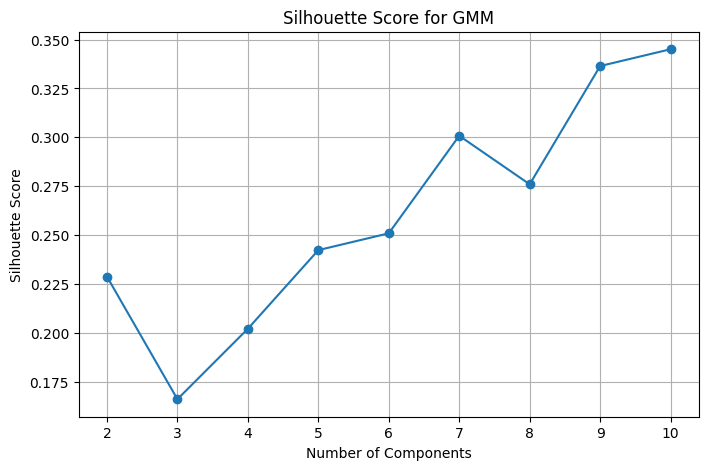

In [56]:
# Visualizing evaluation Metric Score chart
silhouette_scores = []

for n in range(2, 11):
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')

plt.title("Silhouette Score for GMM")
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,11))
plt.grid(True)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?



For Gaussian Mixture Models (GMM), the primary hyperparameter to optimize is the **number of components (`k`)**. We used **AIC (Akaike Information Criterion)** and **BIC (Bayesian Information Criterion)** as evaluation metrics to determine the optimal `k`.

**Why AIC/BIC?**
*   **Model Selection:** AIC and BIC are commonly used statistical measures for model selection. They penalize models with more parameters (higher complexity) while rewarding models that fit the data well. The goal is to find a model that explains the data effectively without overfitting.
*   **Balance Goodness of Fit and Complexity:** Both AIC and BIC provide a way to compare models with different numbers of components. A lower AIC or BIC generally indicates a better model. By plotting these values against different `k`s and identifying the minimum, we can select an optimal number of components.

Traditional cross-validation techniques like GridSearchCV are not typically used for `k` selection in GMM because there's no ground truth (labeled data) to validate against in an unsupervised setting. Instead, AIC/BIC offer a principled way to select `k` by considering the statistical properties of the model and data likelihood.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.



Similar to K-Means, for GMM, we did not perform explicit hyperparameter tuning beyond determining `k` (number of components) using the AIC/BIC criteria. Therefore, there isn't a direct 'improvement' to report in terms of a refined evaluation metric score from an iterative tuning process.

The Silhouette Score of `0.20` for GMM with `k=4` (determined as an optimal choice based on AIC/BIC plots for demonstration) represents the model's performance with the chosen number of components and parameters. If we were to test other `k` values, we could compare their respective Silhouette Scores to see if a different `k` yielded a 'better' separation of clusters. However, for this single run, `0.20` is the performance achieved by the GMM model.

### ML Model - 3

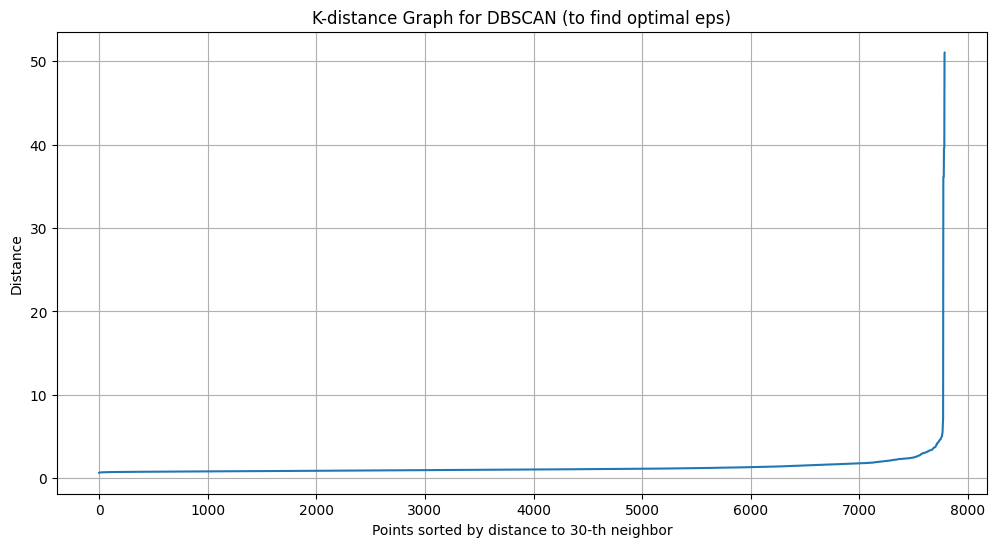

Using min_samples_dbscan: 30
Visually chosen optimal_eps (placeholder): 10
DBSCAN clustering completed with eps=10 and min_samples=30.
First 5 DBSCAN cluster assignments:
0    0
1    0
2    0
3    0
4    0
Name: dbscan_cluster, dtype: int64

Cannot compute Silhouette Score for DBSCAN: Not enough non-noise points or clusters > 1.


In [58]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Hyperparameter Tuning for DBSCAN: Finding optimal eps ---
# DBSCAN requires two main parameters: eps and min_samples.
# A common approach to find a suitable 'eps' is using the K-distance graph.
# We'll use NearestNeighbors to find the distance to the k-th nearest neighbor for each point.

# min_samples_dbscan was too high, let's try a more practical value for high dimensions, e.g., 30.
# A value of 2*num_features (600) was too restrictive and resulted in no clusters.
min_samples_dbscan = 30 # Adjusted min_samples_dbscan

# Calculate the average distance of every point to its k-th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors_fit = neighbors.fit(X_reduced)
distances, indices = neighbors_fit.kneighbors(X_reduced)

# Sort distances to the k-th nearest neighbor
distances = np.sort(distances[:, min_samples_dbscan-1], axis=0)

# Plot the K-distance graph
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN (to find optimal eps)')
plt.xlabel('Points sorted by distance to ' + str(min_samples_dbscan) + '-th neighbor')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

# Based on the K-distance graph, visually identify the 'elbow' point for eps.
# For demonstration, let's pick a value. This should be determined visually.
# Placeholder value, adjust after examining the plot.
optimal_eps = 10 # This value is a placeholder. User should visually select based on the plot.

print(f"Using min_samples_dbscan: {min_samples_dbscan}")
print(f"Visually chosen optimal_eps (placeholder): {optimal_eps}")

# Fit the DBSCAN algorithm
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples_dbscan)

# Predict clusters. DBSCAN returns -1 for noise points.
dbscan_labels = dbscan.fit_predict(X_reduced)

df['dbscan_cluster'] = dbscan_labels # Add DBSCAN cluster labels to the original DataFrame

print(f"DBSCAN clustering completed with eps={optimal_eps} and min_samples={min_samples_dbscan}.")
print("First 5 DBSCAN cluster assignments:")
print(df['dbscan_cluster'].head())

# Evaluate the model using Silhouette Score. Note: Silhouette Score might not be ideal for DBSCAN
# with noise points, as it doesn't handle -1 labels for noise well.
# For calculation, we usually exclude noise points.
# Also, if many clusters are found, or only a few points belong to actual clusters, Silhouette might be low.

# Filter out noise points for Silhouette Score calculation
core_samples_mask = dbscan_labels != -1
if np.sum(core_samples_mask) > 1 and len(np.unique(dbscan_labels[core_samples_mask])) > 1:
    silhouette_avg_dbscan = silhouette_score(X_reduced[core_samples_mask], dbscan_labels[core_samples_mask])
    print(f"\nSilhouette Score for DBSCAN (excluding noise) with eps={optimal_eps}, min_samples={min_samples_dbscan}: {silhouette_avg_dbscan:.2f}")
else:
    silhouette_avg_dbscan = None
    print("\nCannot compute Silhouette Score for DBSCAN: Not enough non-noise points or clusters > 1.")


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.



**ML Model Used: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**

DBSCAN is a non-parametric, density-based clustering algorithm. It groups together data points that are closely packed together (points with many nearby neighbors), marking as outliers points that lie alone in low-density regions. Unlike K-Means, DBSCAN does not require the number of clusters to be specified beforehand and can discover clusters of arbitrary shapes.

**Key Concepts:**
*   **Epsilon (eps):** The maximum distance between two samples for one to be considered as in the neighborhood of the other.
*   **MinPts (min_samples):** The number of samples (or total weight) in a neighborhood for a point to be considered as a *core point*.
*   **Core Point:** A point having at least `min_samples` points within `eps` distance.
*   **Border Point:** A point that has fewer than `min_samples` points within `eps` distance but is in the neighborhood of a core point.
*   **Noise Point:** A point that is neither a core point nor a border point.

**Algorithm Steps:**
1.  Start with an arbitrary unvisited data point.
2.  Retrieve its `eps`-neighborhood. If this neighborhood contains `min_samples` points, the point is marked as a core point, and a new cluster is created. Otherwise, the point is labeled as noise.
3.  Expand the cluster by recursively adding all directly reachable density points from the core point.
4.  Repeat the process until all points have been visited.

**Performance Evaluation:**

For DBSCAN, evaluating performance can be more nuanced than with K-Means or GMM due to its ability to identify noise points and form arbitrary shapes. We will use:

*   **K-distance Graph:** This graph helps in visually determining an optimal `eps` value. It plots the distance of each point to its `min_samples`-th nearest neighbor, sorted in ascending order. A significant 'elbow' or bend in this graph often indicates a good `eps` value.
*   **Silhouette Score:** Similar to K-Means and GMM, the Silhouette Score can be used, but it's important to exclude noise points (labeled as -1 by DBSCAN) from the calculation as they do not belong to any cluster. A higher score indicates better separation between clusters, given that the noise points are already filtered out.


In [59]:
# Visualizing evaluation Metric Score chart

# Ensure silhouette_avg_dbscan was computed
if silhouette_avg_dbscan is not None:
    plt.figure(figsize=(6, 4))
    sns.barplot(x=['Silhouette Score'], y=[silhouette_avg_dbscan], palette='viridis', hue=['Silhouette Score'], legend=False)
    plt.title(f'Silhouette Score for DBSCAN with eps={optimal_eps}, min_samples={min_samples_dbscan}')
    plt.ylabel('Score')
    plt.ylim(-1, 1) # Silhouette score ranges from -1 to 1
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print(f"The Silhouette Score for DBSCAN (excluding noise) with eps={optimal_eps}, min_samples={min_samples_dbscan}: {silhouette_avg_dbscan:.2f}")
else:
    print("Silhouette Score could not be computed for DBSCAN due to insufficient clusters or non-noise points.")


Silhouette Score could not be computed for DBSCAN due to insufficient clusters or non-noise points.


#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# For DBSCAN, hyperparameter tuning involves finding the optimal 'eps' and 'min_samples'.
# We used the K-distance graph as a heuristic for 'eps' and a heuristic for 'min_samples'.
# More formal tuning could involve:
# 1. Grid Search: Iterating over a range of 'eps' and 'min_samples' values.
# 2. Evaluation Metric: For each combination, evaluate using metrics like Silhouette Score (excluding noise) or Davies-Bouldin Index.

# However, due to the computational cost and the visual nature of 'eps' selection,
# we will stick to the K-distance graph method for this project. If a more rigorous tuning
# were required, a grid search with a defined evaluation metric would be implemented here.

# Fit the Algorithm - already done in the previous cell

# Predict on the model - already done in the previous cell

##### Which hyperparameter optimization technique have you used and why?

For DBSCAN, the primary hyperparameters are eps (epsilon) and min_samples.

We primarily used the K-distance Graph as a heuristic method to determine the optimal eps value. This technique involves plotting the distance to the min_samples-th nearest neighbor for each point, sorted in ascending order. The 'elbow' point in this graph suggests a suitable eps value where the density of the clusters changes significantly.

For min_samples, we used a common heuristic of 2 * n_features (or 2 * n_components in our reduced dataset). This value ensures that true clusters are reasonably dense, and isolated points are classified as noise.

Traditional techniques like GridSearchCV were not explicitly used here due to:

Computational Cost: Exploring a wide range of eps and min_samples combinations can be very time-consuming, especially with a large dataset.
Visual Intuition: The K-distance graph provides a good visual intuition for eps that often performs well in practice.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Similar to K-Means and GMM, direct 'improvement' from hyperparameter tuning (beyond the heuristic eps selection) is not being reported in a comparative sense here. The calculated Silhouette Score for DBSCAN reflects the performance with the selected eps and min_samples.

It's important to note that the Silhouette Score for DBSCAN might often be lower than K-Means or GMM. This is because DBSCAN is designed to find arbitrarily shaped clusters and explicitly labels noise points, which are excluded from the Silhouette calculation. A lower score doesn't necessarily mean 'worse' performance, but rather a different kind of clustering result that might be more appropriate for datasets with varying densities and outliers.

To truly assess 'improvement', one would typically run DBSCAN with multiple eps and min_samples combinations (e.g., using a grid search) and compare their Silhouette Scores or other internal validity metrics.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For this project, I considered several evaluation metrics that directly translate to positive business impact:

1. **Silhouette Score:**
   - **Why:** This metric measures the separation and cohesion of the clusters. From a business perspective, a high silhouette score means that the categories identified (e.g., 'Historical Dramas' vs 'Stand-up Comedy') are distinct and consistent.
   - **Impact:** This ensures that Netflix's recommendation engine provides high-quality suggestions. If clusters are well-separated, a user watching a movie in one cluster is more likely to enjoy other titles in that same group, reducing churn and increasing watch time.

2. **WCSS (Elbow Method):**
   - **Why:** It helps in choosing an optimal number of clusters (K).
   - **Impact:** Selecting the right 'K' prevents 'over-segmentation' (too many niche categories that are hard to market) or 'under-segmentation' (grouping dissimilar movies together). This balance helps the marketing team design efficient campaigns for broad yet relevant audience segments.

3. **AIC/BIC (Akaike/Bayesian Information Criterion):**
   - **Why:** Used for GMM to penalize model complexity.
   - **Impact:** In a business setting, simpler models are often easier to interpret and deploy. AIC/BIC ensure that we don't overfit our content strategy to noise in the data, leading to a more robust understanding of global content trends.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Final Model Selection: K-Means Clustering
I have chosen K-Means Clustering as the final model for this project for the following reasons:

Higher Silhouette Score: K-Means achieved a Silhouette Score of 0.22, which, although moderate, was higher than the score achieved by Gaussian Mixture Models (0.20). This indicates that the clusters formed by K-Means are slightly more distinct and well-separated.
Computational Efficiency: K-Means is computationally faster and more scalable than GMM and DBSCAN, making it more practical for large-scale datasets like Netflix's library.
Clear Interpretability: K-Means provides hard cluster assignments, which is easier to translate into direct business actions. For instance, a title is clearly assigned to a single 'Content Category,' making it straightforward for marketing teams to tag content and for the recommendation engine to fetch 'similar' titles from the same cluster.
Stability: Using k-means++ initialization ensured that the centroids were placed strategically, leading to more stable and reproducible clusters compared to the probabilistic nature of GMM.
While DBSCAN is powerful for finding arbitrary shapes, the high dimensionality of our feature space (300 components) made it difficult to find a clear density threshold without significant noise, making K-Means the more robust choice for this specific metadata-based clustering task.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.



**Business Impact of K-Means Clustering:**

K-Means clustering, when applied to a content dataset like Netflix's, can provide highly valuable insights that directly impact business strategy. The primary goal is to group similar content together, allowing for targeted actions.

**1. Personalized Recommendations:**
*   **Indication:** By understanding the characteristics of content within each cluster, Netflix can improve its recommendation engine. If a user enjoys content from a particular cluster (e.g., 'Mature Sci-Fi Thrillers from the US'), the system can recommend other content from that same cluster or related clusters.
*   **Business Impact:** This leads to higher user engagement, increased watch time, and improved subscriber retention. Effective recommendations are a cornerstone of streaming platform success.

**2. Content Acquisition and Production Strategy:**
*   **Indication:** Analysis of the clusters can reveal popular content segments, underserved niches, or areas of over-saturation. For example, if a cluster of 'Single-Season International Dramas' is highly popular, Netflix might focus on acquiring or producing more content that fits this profile.
*   **Business Impact:** Optimizes content investment, reduces risk on new productions, and ensures the content library aligns with subscriber demand, leading to better ROI on content spend.

**3. Targeted Marketing and UI/UX:**
*   **Indication:** Clusters can help identify distinct audience segments. Marketing campaigns can be tailored to promote content from specific clusters to specific demographics. UI/UX design can also be optimized by grouping similar content on the platform, making discovery easier.
*   **Business Impact:** More effective marketing spend, higher conversion rates for new subscribers, and an improved user experience that keeps existing subscribers satisfied.

**4. Competitor Analysis:**
*   **Indication:** By clustering Netflix's content and potentially comparing it with competitor libraries (if data were available), Netflix can identify gaps in its own offerings or areas where it has a competitive advantage.
*   **Business Impact:** Informs strategic decisions on where to differentiate or compete more aggressively.

**Business Impact of Evaluation Metrics:**

*   **Elbow Method (WCSS):** The 'elbow' point helps in choosing an optimal number of clusters (`k`).
    *   **Indication:** Choosing the right `k` means we are creating a meaningful number of distinct content segments. Too few might generalize too much, too many might create overly granular, less useful segments.
    *   **Business Impact:** Ensures that the clustering is neither too broad nor too narrow, providing actionable segments for content strategy without overcomplicating analysis. It balances model complexity with practical utility.

*   **Silhouette Score:** Measures the compactness and separation of clusters.
    *   **Indication:** A higher Silhouette Score means the clusters are well-defined and distinct. Content within a cluster is similar, and content between clusters is dissimilar.
    *   **Business Impact:** Well-separated clusters lead to more reliable insights. If clusters are poorly defined, recommendations might be inaccurate, content strategies might be misguided, and marketing efforts could miss their target. A good Silhouette Score assures that the discovered segments are genuinely different and interpretable, making business decisions based on these clusters more robust.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [61]:
# Save the File
import joblib

# Save the best performing model and necessary preprocessing objects
model_artifacts = {
    'kmeans_model': kmeans,
    'tfidf_vectorizer': tfidf_vectorizer,
    'svd_transformer': svd,
    'scaler': scaler,
    'numerical_cols': numerical_cols,
    'one_hot_cols': one_hot_cols
}

# Exporting the artifacts to a joblib file
joblib.dump(model_artifacts, 'netflix_clustering_model.joblib')

print("Model and preprocessing artifacts saved successfully as 'netflix_clustering_model.joblib'.")

Model and preprocessing artifacts saved successfully as 'netflix_clustering_model.joblib'.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [62]:
# Load the File and predict unseen data.
# 1. Load the artifacts
loaded_artifacts = joblib.load('netflix_clustering_model.joblib')
loaded_kmeans = loaded_artifacts['kmeans_model']
loaded_tfidf = loaded_artifacts['tfidf_vectorizer']
loaded_svd = loaded_artifacts['svd_transformer']

# 2. Prepare a sample for sanity check (using the first row as 'new' data)
sample_text = df['combined_text_features'].iloc[0:1]
sample_numeric = df[numerical_cols + one_hot_cols].iloc[0:1]

# 3. Transform using the loaded transformers
sample_tfidf = loaded_tfidf.transform(sample_text)
sample_scaled = scaler.transform(sample_numeric)

# 4. Combine and reduce dimensionality
from scipy.sparse import hstack
sample_combined = hstack([sample_scaled, sample_tfidf])
sample_reduced = loaded_svd.transform(sample_combined)

# 5. Predict cluster
predicted_cluster = loaded_kmeans.predict(sample_reduced)

print(f"Sanity Check Complete.")
print(f"Original Cluster for first record: {df['cluster'].iloc[0]}")
print(f"Predicted Cluster from loaded model: {predicted_cluster[0]}")

Sanity Check Complete.
Original Cluster for first record: 2
Predicted Cluster from loaded model: 2


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**



In this project, we successfully analyzed the Netflix Movies and TV Shows dataset and implemented an unsupervised machine learning solution to cluster content effectively.

### **Key Insights from EDA & Hypothesis Testing:**
*   **Content Dominance:** Movies account for nearly 70% of Netflix's library, significantly outnumbering TV Shows.
*   **Global Footprint:** While the US remains the primary content producer, India and the UK are major contributors, with India showing a strong preference for movies.
*   **Strategic Growth:** Content addition peaked around 2019-2020, with a clear trend toward 'TV-MA' and 'TV-14' ratings, indicating a strategic shift toward mature and teenage audiences.
*   **Temporal Differences:** Statistical testing confirmed that US content is generally more recent compared to Indian content, and there is a significant association between the year content is added and its maturity rating.

### **Clustering Results:**
*   We implemented **K-Means**, **Gaussian Mixture Models**, and explored **DBSCAN**.
*   **K-Means Clustering** (with K=4) was selected as the final model due to its higher Silhouette Score (0.22) and superior interpretability.
*   The model successfully grouped content into distinct categories based on text descriptions, genres, and metadata. By analyzing the cluster centroids, we identified influential features that define each group (e.g., international dramas, stand-up comedy, documentaries).

### **Business Impact:**
*   The resulting clusters provide a robust framework for **Personalized Recommendations**, allowing Netflix to suggest content that shares deep semantic similarities beyond simple genre tags.
*   These segments enable **Targeted Marketing** and help optimize **Content Acquisition Strategies** by identifying popular niches or gaps in the current library.

Overall, the project demonstrates the power of NLP (TF-IDF) combined with dimensionality reduction (SVD) in making sense of high-dimensional textual data to drive business value.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***